# C2: Sức mạnh Biểu diễn của Quantum Kernel (ZZFeatureMap)

## 1. Bối cảnh Khoa học
C2 giải quyết câu hỏi trọng tâm: **Tại sao** quantum kernel $K_{ZZ}$ lại vượt trội so với các classical kernel (như đa thức hay RBF) trong bài toán phát hiện xâm nhập mạng (IDS) trên tập dữ liệu NSL-KDD?

Kết quả từ Đóng góp 1 (C1) đã thiết lập một tiền đề quan trọng: Mặc dù PCA đảm bảo tính trực giao tuyến tính (Pearson correlation bằng 0), nhưng **Spearman correlations phi tuyến vẫn tồn tại đáng kể** giữa các Principal Components — ví dụ PC0–PC2 ($r=+0.40$) và PC1–PC2 ($r=-0.44$). 
Mạch `ZZFeatureMap` mã hóa chính xác các tương tác phi tuyến theo từng cặp này thông qua các cổng pha vướng víu lượng tử (ZZ phase gates), qua đó cung cấp lời giải thích cơ chế rõ ràng cho lợi thế lượng tử.

## 2. Các Giả thuyết Nghiên cứu

| ID | Nội dung Giả thuyết | Đánh giá qua |
|---|---|---|
| **H1** | `ZZFeatureMap` mã hóa các cross-term $x_i \cdot x_j$ dưới dạng ZZ phase gate, tạo ra không gian đặc trưng phong phú hơn so với classical $K_{\text{poly2}}$. | Spearman Bridge & Topology |
| **H2** | CKA($K_{ZZ}$, $K_{\text{ideal}}$) > CKA($K_{\text{poly2}}$, $K_{\text{ideal}}$) trên NSL-KDD (Quantum kernel căn chỉnh hình học với nhãn lớp tốt hơn). | Centered Kernel Alignment |
| **H3** | Trạng thái lượng tử kích hoạt bởi lớp Attack có entanglement entropy (độ vướng víu) cao hơn một cách có hệ thống so với lớp Normal. | Von Neumann Entropy |
| **H4** | Mạch với `reps=2` hoặc `3` nằm trong vùng an toàn (informative regime), không bị hiện tượng suy giảm thông tin (kernel concentration) với $n=4$ qubit. | Kernel Concentration |

## 3. Lộ trình Thực hiện (Roadmap)
Notebook này được cấu trúc thành các giai đoạn nối tiếp nhau nhằm chứng minh các giả thuyết trên:

* **Giai đoạn 1: Tiền xử lý & Khởi tạo (Phần 1 - 3)**
  * Tải dữ liệu tuân thủ tuyệt đối Zero-leakage pipeline từ C1.
  * Trích xuất tập subsample có tính tái lập (stratified).
  * Tính toán các ma trận Kernel: Quantum ($K_{ZZ}$), Poly-2, RBF và Ideal Label.
* **Giai đoạn 2: Phân tích Hình học Kernel (Phần 4 - 6)**
  * Trực quan hóa cấu trúc khối (Block structure) qua Heatmap.
  * Đo lường độ tương thích (CKA) với cấu trúc nhãn thực tế để kiểm chứng H2.
  * Phân tích Eigenspectrum và Effective Rank để đo lường độ đa dạng của không gian đặc trưng.
* **Giai đoạn 3: Phân tích Bản chất Lượng tử (Phần 7 - 9)**
  * Đánh giá khả năng biểu diễn (Expressibility) qua độ lệch KL so với phân phối Haar.
  * Phân tích Entanglement Entropy giữa các lớp lưu lượng mạng để kiểm chứng H3.
  * Đánh giá hiện tượng Kernel Concentration để kiểm chứng H4.
* **Giai đoạn 4: Thực nghiệm & Tổng hợp (Phần 10 - 12)**
  * Đối chiếu biên quyết định (Decision Boundary) và hiệu suất phân lớp (QSVM vs CSVM).
  * Xây dựng cầu nối Spearman: Ánh xạ kết quả thống kê lên topology mạch lượng tử.
  * Đóng gói toàn bộ metrics vào báo cáo định dạng JSON.

## 4. Luồng Dữ liệu Đầu cuối (Data Flow)

```text
NSL-KDD Raw (41D) 
  → Tiền xử lý C1 (SelectKBest + PCA Pareto) 
  → 4D Features ∈ [0, π]
      ↓
ZZFeatureMap(reps=2, full entanglement) 
  → Tạo trạng thái lượng tử |φ(x)⟩
      ↓
Tính toán K_ZZ = |⟨φ(x)|φ(z)⟩|²
  → So sánh với K_poly2, K_RBF, K_ideal
      ↓
Trích xuất Metrics: CKA, Eigenspectrum, Expressibility, Entropy, Concentration

In [11]:
import sys, os
import numpy as np
import pandas as pd
import joblib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import json
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display
# Qiskit imports
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector, partial_trace, entropy as von_neumann_entropy

# Scikit-learn
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics.pairwise import polynomial_kernel, rbf_kernel
from sklearn.model_selection import train_test_split

# Tính toán khoa học
from scipy.stats import spearmanr, mannwhitneyu, beta as beta_dist
from scipy.special import kl_div

# ── Hằng số toàn cục ─────────────────────────────────────────────────────────
N_QUBITS               = 4
N_SUBSAMPLE            = 300       # Ngân sách tính kernel chính C2 (~45K lần tính mỗi ma trận)
N_CONC                 = 150       # Subsample nhỏ hơn cho vòng quét concentration 5 reps
RANDOM_STATE           = 42
N_BOOTSTRAP            = 200       # Số lần lặp bootstrap để tính khoảng tin cậy
N_EXPR_PAIRS           = 2000      # Số cặp ngẫu nhiên để phân tích expressibility
HILBERT_DIM            = 16        # 2^4 — kích thước không gian Hilbert
ZZ_REPS_TARGET         = 2        # Số lần lặp circuit trong C2 (phân tích expressibility)
ZZ_ENTANGLEMENT_TARGET = "full"   # Kiểu entanglement: full (tất cả 6 cặp qubit)

# BUG FIX: đường dẫn tương đối từ notebooks/ → thư mục reports/ ở gốc project
REPORTS_DIR = "../reports"
os.makedirs(REPORTS_DIR, exist_ok=True)

print("Import hoàn tất.")
print(f"Cấu hình: N_SUBSAMPLE={N_SUBSAMPLE}, reps={ZZ_REPS_TARGET}, entanglement={ZZ_ENTANGLEMENT_TARGET!r}")

Import hoàn tất.
Cấu hình: N_SUBSAMPLE=300, reps=2, entanglement='full'


## 1. Các Hàm Tiện Ích Phục Vụ Phân Tích Khả Năng Biểu Diễn

* **Đánh giá Cấu trúc Kernel:** Tính toán Centered Kernel Alignment (CKA), Hạng hiệu dụng (Effective Rank), và Tỷ lệ khối (Block Ratio) để đo lường mức độ phong phú của không gian đặc trưng và khả năng phân tách nhãn.
* **Đo lường Thuộc tính Lượng tử:** Cung cấp hàm tính Entanglement Entropy (Von Neumann) và độ lệch KL (KL Divergence) so với phân phối Haar nhằm đánh giá mức độ vướng víu và khả năng biểu diễn (expressibility) của mạch.
* **Công cụ Thống kê & Dữ liệu:** Tích hợp các hàm tính khoảng tin cậy Bootstrap 95% (Bootstrap CI) và lấy mẫu phân tầng (Stratified Subsample) để đảm bảo độ tin cậy thống kê và tính tái lập tuyệt đối cho các thử nghiệm.

In [12]:
def build_quantum_kernel_cfg(reps=2, entanglement="full"):
    """Xây dựng Quantum Kernel có tham số; có thể quét theo reps/entanglement."""
    feature_map = zz_feature_map(feature_dimension=N_QUBITS,
                                 reps=reps,
                                 entanglement=entanglement)
    fidelity = ComputeUncompute(sampler=StatevectorSampler())
    return FidelityQuantumKernel(feature_map=feature_map,
                                 fidelity=fidelity,
                                 enforce_psd=True)

def center_kernel(K):
    """Căn giữa kép ma trận kernel: H K H, với H = I - (1/n)11^T."""
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def cka(K1, K2):
    """Centered Kernel Alignment (Kornblith et al., 2019).
    CKA(K1, K2) = tr(K1c K2c) / (||K1c||_F * ||K2c||_F)
    """
    K1c = center_kernel(K1)
    K2c = center_kernel(K2)
    numerator   = np.trace(K1c @ K2c)
    denominator = (np.linalg.norm(K1c, 'fro') * np.linalg.norm(K2c, 'fro'))
    if denominator == 0:
        return 0.0
    return float(numerator / denominator)

def effective_rank(K):
    """Effective rank = (tổng sigma_i)^2 / (tổng sigma_i^2).
    Phạm vi: [1, N]. Giá trị càng cao = không gian feature càng phong phú.
    """
    sigmas = np.linalg.svd(K, compute_uv=False)
    sigmas = sigmas[sigmas > 1e-12]
    if len(sigmas) == 0:
        return 1.0
    return float(sigmas.sum()**2 / (sigmas**2).sum())

def bootstrap_ci(statistic_fn, K, n_bootstrap=200, ci=0.95, seed=42):
    """Khoảng tin cậy bootstrap 95% cho một thống kê vô hướng trên ma trận kernel đối xứng.
    Sử dụng lấy mẫu lại đồng thời hàng/cột: K_boot = K[ix_(idx, idx)].
    """
    rng = np.random.RandomState(seed)
    n = K.shape[0]
    stats = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        K_boot = K[np.ix_(idx, idx)]
        stats.append(statistic_fn(K_boot))
    stats = np.array(stats)
    alpha = (1 - ci) / 2
    lo = float(np.percentile(stats, 100 * alpha))
    hi = float(np.percentile(stats, 100 * (1 - alpha)))
    return lo, hi

def cka_with_ci(K1, K2, n_bootstrap=N_BOOTSTRAP):
    """Tính CKA kèm khoảng tin cậy bootstrap (lấy mẫu lại hàng/cột K1, K2 đồng thời)."""
    val = cka(K1, K2)
    rng = np.random.RandomState(RANDOM_STATE)
    n = K1.shape[0]
    stats = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        K1b = K1[np.ix_(idx, idx)]
        K2b = K2[np.ix_(idx, idx)]
        stats.append(cka(K1b, K2b))
    stats = np.array(stats)
    lo = float(np.percentile(stats, 2.5))
    hi = float(np.percentile(stats, 97.5))
    return val, lo, hi

def kl_divergence_from_haar(fidelities, n_qubits, n_bins=50):
    """D_KL(P_ZZ || P_Haar) trong đó P_Haar ~ Beta(1, 2^n - 1).
    D_KL càng thấp nghĩa là phân phối circuit càng gần Haar-random (biểu diễn phong phú hơn).
    """
    N_haar = 2**n_qubits - 1  # Beta(1, N_haar)
    bins = np.linspace(0, 1, n_bins + 1)
    counts, _ = np.histogram(fidelities, bins=bins, density=False)
    total = counts.sum()
    if total == 0:
        return float('inf')
    p_obs = counts / total

    bin_mid = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]
    p_haar = beta_dist.pdf(bin_mid, a=1, b=N_haar) * bin_width
    p_haar = p_haar / p_haar.sum()

    eps = 1e-12
    kl = np.sum(np.where(p_obs > eps, p_obs * np.log((p_obs + eps) / (p_haar + eps)), 0.0))
    return float(kl)

def block_ratio(K, n_class0):
    """Tỷ lệ giá trị trung bình trong cùng lớp / khác lớp.
    n_class0: số mẫu Normal (khối đầu tiên trong K đã sắp xếp).
    """
    n = K.shape[0]
    n1 = n_class0
    n2 = n - n1
    K_nn = K[:n1, :n1]
    K_aa = K[n1:, n1:]
    K_na = K[:n1, n1:]
    within = (K_nn.sum() + K_aa.sum()) / (n1**2 + n2**2)
    across = K_na.sum() / (n1 * n2)
    ratio  = within / (across + 1e-12)
    return within, across, ratio

def compute_entanglement_entropy(x, reps=2, entanglement="full"):
    """Von Neumann entropy của bipartition {0,1}|{2,3} cho trạng thái ZZFeatureMap.
    Trả về S trong [0, 2] bit.
    """
    circuit = zz_feature_map(N_QUBITS, reps=reps, entanglement=entanglement)
    bound   = circuit.assign_parameters(dict(zip(circuit.parameters, x)))
    sv      = Statevector(bound)
    rho_A   = partial_trace(sv, qargs=(2, 3))   # trace out các qubit {2,3}
    return float(von_neumann_entropy(rho_A, base=2))

def stratified_subsample(X, y, sample_size):
    if sample_size >= len(y):
        raise ValueError(
            f"sample_size ({sample_size}) phải nhỏ hơn kích thước dataset ({len(y)})."
        )
    discard_fraction = 1.0 - sample_size / len(y)
    X_sub, _, y_sub, _ = train_test_split(
        X, y,
        test_size=discard_fraction,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    return X_sub, y_sub

print("Các hàm tiện ích đã được định nghĩa.")

Các hàm tiện ích đã được định nghĩa.


# Nền tảng Toán học của ZZFeatureMap Kernel

## 1.1 Kiến trúc Circuit

Với $n=4$ qubit và $r$ lần lặp, mỗi lần lặp áp dụng:

$$U_{\text{rep}}(\mathbf{x}) = U_{ZZ}(\mathbf{x}) \cdot H^{\otimes 4} \cdot U_{\phi}(\mathbf{x})$$

trong đó:
- $H^{\otimes 4}$: Lớp Hadamard tạo superposition đồng đều
- $U_{\phi}(\mathbf{x}) = \bigotimes_{i=0}^{3} P(2x_i)$: Single-qubit phase gate mã hóa từng feature
- $U_{ZZ}(\mathbf{x}) = \prod_{(i,j) \in \mathcal{E}} \exp\!\left(i\,(\pi - x_i)(\pi - x_j)\, Z_i \otimes Z_j\right)$: ZZ gate tạo entanglement

Với **full entanglement**, $\mathcal{E} = \{(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)\}$ — tất cả $\binom{4}{2} = 6$ cặp.

## 1.2 Mã hóa qua ZZ Gate

Góc xoay ZZ phase cho cặp $(i,j)$ là:

$$\theta_{ij} = 2(\pi - x_i)(\pi - x_j)$$

Khai triển: $\theta_{ij} = 2\pi^2 - 2\pi(x_i + x_j) + 2x_ix_j$

Cross-term $x_ix_j$ được mã hóa như một **quantum phase** — đây là tương tác phi tuyến mà classical linear kernel không thể biểu diễn.

## 1.3 Quantum Kernel như Khai triển Feature

$$K_{ZZ}(\mathbf{x}, \mathbf{z}) = |\langle 0 | U^\dagger(\mathbf{z})\, U(\mathbf{x}) | 0 \rangle|^2 = \sum_{S \subseteq [n]} c_S\, \phi_S(\mathbf{x})\, \phi_S^*(\mathbf{z})$$

Các hàm feature $\phi_S$ bao gồm:
- **Hằng số**: $\phi_\emptyset = 1$
- **Tuyến tính**: $\phi_{\{i\}} \sim e^{i(x_i - z_i)}$
- **Cross-term bậc hai**: $\phi_{\{i,j\}} \sim e^{i[(\pi-x_i)(\pi-x_j) - (\pi-z_i)(\pi-z_j)]}$ cho tất cả 6 cặp

## 1.4 So sánh: ZZ vs. Classical Poly-2 Kernel

| Thuộc tính | $K_{\text{poly2}}$ | $K_{ZZ}$ (reps=2) |
|---|---|---|
| Chiều không gian feature | $\binom{4+2}{2} = 15$ (đơn thức thực) | $2^4 = 16$ (hàm mũ phức) |
| Cross-term được mã hóa | Tất cả $\binom{4}{2}=6$ cặp (thực) | Tất cả 6 cặp × 3 lần lặp (phức, có re-mixing) |
| Interference | Không có | Quantum constructive/destructive |
| Đảm bảo PSD | Có ($\gamma > 0$) | Có (`enforce_psd=True`) |

Với $\text{reps}=3$ và lớp H tái trộn giữa các lần lặp, ZZFeatureMap hiệu quả xếp chồng 3 lớp mã hóa cross-term — tương đương đa thức bậc 3 trong các số hạng tương tác ZZ.

## 1.5 Cầu nối đến C1: Spearman Correlations → ZZ Pairs

C1 tìm thấy Spearman correlations tồn tại giữa các PCA component dù trực giao:

| Cặp PCA | Spearman $r$ | Cặp ZZ | Góc ZZ |
|---|---|---|---|
| PC0 – PC2 | $r \approx +0.40$ | $(i,j)=(0,2)$ | $\theta_{02} = 2(\pi-x_0)(\pi-x_2)$ |
| PC1 – PC2 | $r \approx -0.44$ | $(i,j)=(1,2)$ | $\theta_{12} = 2(\pi-x_1)(\pi-x_2)$ |

Đây là các **ZZ gate then chốt** trong topology full-entanglement. Các tương tác tích phi tuyến $x_0 x_2$ và $x_1 x_2$ — mà linear SVM hậu PCA không thể nắm bắt — được mã hóa tường minh dưới dạng quantum phase rotation trong $K_{ZZ}$.

> **Kết luận cơ chế:** Lợi thế lượng tử trên NSL-KDD không phải điều bí ẩn. ZZFeatureMap mã hóa đặc biệt các tương tác feature phi tuyến mà phân tích Spearman đã xác định là quan trọng về mặt cấu trúc trong dữ liệu IDS.

## 2. Tải Dữ Liệu và Chuẩn Bị Subsample (Zero-Leakage Pipeline)
Bước này tập trung nạp dữ liệu và biến đổi qua các transformer đã được huấn luyện sẵn, nhằm chuẩn bị dữ liệu đầu vào cho các phân tích lượng tử:
* **Áp dụng Pipeline:** Tải tập Train/Test (CSV) và đi qua `SelectKBest`, `PCA`, `MinMaxScaler`. Chỉ dùng `transform()` (không `fit`) để tuân thủ tuyệt đối nguyên tắc zero-leakage, giới hạn giá trị đặc trưng trong khoảng không gian pha `[0, π]`.
* **Trích xuất Subsample C2:** Lấy mẫu phân tầng (stratified) từ tập Test với `random_state` cố định. Việc này tạo ra một tập con có tính tái lập hoàn toàn để so sánh các kernel.
* **Tiền xử lý Trực quan hóa:** Sắp xếp dữ liệu theo nhãn (Normal trước, Attack sau) để làm nổi bật cấu trúc khối (block structure) khi vẽ heatmap ở các bước sau.

In [13]:
PROCESSED_DATA_DIR = "../data/processed_data"
MODELS_DIR         = "../models"

# Các cột nhãn có trong CSV — loại khỏi ma trận feature
LABEL_COLS = ['label', 'label_binary', 'label_multiclass', 'attack_category']

# Tải CSV
train_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "NSL_KDD_Train_Cleaned.csv"))
test_df  = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "NSL_KDD_Test_Cleaned.csv"))

print("Đã tải CSV:")
print(f"  Train : {train_df.shape[0]:,} hàng x {train_df.shape[1]} cột")
print(f"  Test  : {test_df.shape[0]:,}  hàng x {test_df.shape[1]} cột")

# Tải các transformer đã huấn luyện
# QUAN TRONG: chi transform() — khong fit() lai de dam bao zero-leakage
selector = joblib.load(os.path.join(MODELS_DIR, "feature_selector_k20.joblib"))
pca      = joblib.load(os.path.join(MODELS_DIR, "pca_4components.joblib"))
scaler   = joblib.load(os.path.join(MODELS_DIR, "scaler_minmax_pi.joblib"))

print(f"\nDa tai cac transformer:")
print(f"  selector : SelectKBest (k={selector.k})")
print(f"  pca      : PCA (n_components={pca.n_components_})")
print(f"  scaler   : MinMaxScaler (feature_range={scaler.feature_range})")

# Tách feature và nhãn 
feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]

X_train_raw  = train_df[feature_cols].values.astype(np.float64)
X_test_raw   = test_df[feature_cols].values.astype(np.float64)
y_train_full = train_df['label_binary'].values.astype(int)
y_test_full  = test_df['label_binary'].values.astype(int)

print(f"\nMa tran feature tho:")
print(f"  X_train_raw : {X_train_raw.shape}")
print(f"  X_test_raw  : {X_test_raw.shape}")

# Áp dụng pipeline: selector → PCA → MinMaxScaler → clip về [0, π] 
X_train_sel = selector.transform(X_train_raw)
X_test_sel  = selector.transform(X_test_raw)

X_train_pca = pca.transform(X_train_sel)
X_test_pca  = pca.transform(X_test_sel)

X_train_full = np.clip(scaler.transform(X_train_pca), 0, np.pi)
X_test_full  = np.clip(scaler.transform(X_test_pca),  0, np.pi)

print(f"\nSau toan bo pipeline (selector -> PCA -> scaler -> clip[0, pi]):")
print(f"  X_train_full : {X_train_full.shape}  pham vi [{X_train_full.min():.4f}, {X_train_full.max():.4f}]")
print(f"  X_test_full  : {X_test_full.shape}   pham vi [{X_test_full.min():.4f}, {X_test_full.max():.4f}]")
assert X_train_full.shape[1] == N_QUBITS, f"Mong doi {N_QUBITS} feature, nhan duoc {X_train_full.shape[1]}"
assert X_test_full.shape[1]  == N_QUBITS, f"Mong doi {N_QUBITS} feature, nhan duoc {X_test_full.shape[1]}"

# Tái tạo chính xác subsample C2 
discard_fraction = 1.0 - N_SUBSAMPLE / len(y_test_full)
X_c2, _, y_c2, _ = train_test_split(
    X_test_full, y_test_full,
    test_size=discard_fraction,
    stratify=y_test_full,
    random_state=RANDOM_STATE,
)

assert X_c2.shape == (N_SUBSAMPLE, N_QUBITS), f"Kich thuoc subsample C2 khong khop: {X_c2.shape}"

# Sắp xếp theo nhãn lớp để trực quan hóa heatmap (Normal trước, Attack sau)
sort_idx    = np.argsort(y_c2)
X_c2_sorted = X_c2[sort_idx]
y_c2_sorted = y_c2[sort_idx]
n_normal    = int(np.sum(y_c2_sorted == 0))
n_attack    = int(np.sum(y_c2_sorted == 1))

print(f"\nSubsample C2 (N={N_SUBSAMPLE}, seed={RANDOM_STATE}):")
print(f"  Normal (lop 0): {n_normal} mau")
print(f"  Attack (lop 1): {n_attack} mau")
print(f"  Can bang      : {n_normal/N_SUBSAMPLE:.1%} / {n_attack/N_SUBSAMPLE:.1%}")


Đã tải CSV:
  Train : 125,973 hàng x 126 cột
  Test  : 22,544  hàng x 126 cột

Da tai cac transformer:
  selector : SelectKBest (k=20)
  pca      : PCA (n_components=4)
  scaler   : MinMaxScaler (feature_range=(0.0, 3.141592653589793))

Ma tran feature tho:
  X_train_raw : (125973, 122)
  X_test_raw  : (22544, 122)

Sau toan bo pipeline (selector -> PCA -> scaler -> clip[0, pi]):
  X_train_full : (125973, 4)  pham vi [0.0000, 3.1416]
  X_test_full  : (22544, 4)   pham vi [0.0044, 3.1416]

Subsample C2 (N=300, seed=42):
  Normal (lop 0): 129 mau
  Attack (lop 1): 171 mau
  Can bang      : 43.0% / 57.0%


## 3. Tính Toán Các Ma Trận Kernel
Bước này thực hiện tính toán các ma trận kernel trên tập dữ liệu con đã chuẩn bị, làm cơ sở cho việc phân tích hình học và so sánh hiệu suất:
* **Quantum Kernel (ZZFeatureMap):** Tính toán ma trận lượng tử $K_{ZZ}$ và kiểm tra tính hợp lệ (các phần tử trên đường chéo chính phải $\ge 0.99$).
* **Classical Kernels (Poly-2 & RBF):** Tính toán và chuẩn hóa ma trận Polynomial bậc 2 và RBF cổ điển để làm baseline đối chiếu.
* **Ideal Label Kernel:** Xây dựng ma trận hạt nhân lý tưởng dựa trên nhãn thực tế (cùng lớp = +1, khác lớp = -1). Đây là mốc chuẩn (ground-truth) để tính toán Kernel Target Alignment (KTA) ở các bước tiếp theo.

In [14]:
import time

print("Dang tinh quantum kernel K_ZZ (reps=2, full entanglement)...")
print(f"  Kich thuoc ma tran: {N_SUBSAMPLE}x{N_SUBSAMPLE} = {N_SUBSAMPLE**2:,} lan tinh")
t0 = time.time()
qkernel = build_quantum_kernel_cfg(reps=ZZ_REPS_TARGET, entanglement=ZZ_ENTANGLEMENT_TARGET)
K_quantum = qkernel.evaluate(X_c2_sorted)
t_q = time.time() - t0
print(f"  Hoan thanh trong {t_q/60:.1f} phut")

# Kiem tra so bo: duong cheo phai >= 0.999 (fidelity cua trang thai voi chinh no)
diag_min = np.diag(K_quantum).min()
print(f"  Gia tri nho nhat duong cheo: {diag_min:.6f}  (mong doi >= 0.999)")
assert diag_min >= 0.99, f"Kiem tra duong cheo kernel that bai: {diag_min:.6f}"

# Classical poly-2 kernel: K(x,z) = (gamma*x·z + 1)^2, gamma = 1/n_features
print("\nDang tinh classical poly-2 kernel...")
K_poly2 = polynomial_kernel(X_c2_sorted, degree=2, gamma=1.0/N_QUBITS, coef0=1.0)
K_poly2 = K_poly2 / K_poly2.max()  # chuan hoa ve [0,1] de so sanh CKA cong bang
print(f"  Pham vi K_poly2: [{K_poly2.min():.4f}, {K_poly2.max():.4f}]")

# Classical RBF kernel: gamma = 1 / (n_features * X.var())
print("Dang tinh classical RBF kernel...")
gamma_scale = 1.0 / (N_QUBITS * X_c2_sorted.var())
K_rbf = rbf_kernel(X_c2_sorted, gamma=gamma_scale)
print(f"  Pham vi K_RBF: [{K_rbf.min():.4f}, {K_rbf.max():.4f}]  (gamma={gamma_scale:.6f})")

# Ideal label kernel: K_ideal[i,j] = +1 neu y_i==y_j, -1 nguoc lai
# Bieu dien kernel hoan hao biet cau truc lop ground-truth
y_pm1   = 2 * y_c2_sorted.astype(float) - 1
K_ideal = np.outer(y_pm1, y_pm1)

print(f"\nTat ca cac kernel da duoc tinh.")
print(f"Kich thuoc: K_quantum={K_quantum.shape}, K_poly2={K_poly2.shape}, K_rbf={K_rbf.shape}, K_ideal={K_ideal.shape}")

Dang tinh quantum kernel K_ZZ (reps=2, full entanglement)...
  Kich thuoc ma tran: 300x300 = 90,000 lan tinh
  Hoan thanh trong 5.4 phut
  Gia tri nho nhat duong cheo: 1.002010  (mong doi >= 0.999)

Dang tinh classical poly-2 kernel...
  Pham vi K_poly2: [0.0509, 1.0000]
Dang tinh classical RBF kernel...
  Pham vi K_RBF: [0.0129, 1.0000]  (gamma=0.356116)

Tat ca cac kernel da duoc tinh.
Kich thuoc: K_quantum=(300, 300), K_poly2=(300, 300), K_rbf=(300, 300), K_ideal=(300, 300)


## 4. Trực quan hóa Heatmap Ma trận Kernel
Vẽ biểu đồ heatmap để trực quan hóa và so sánh cấu trúc hình học của ba ma trận kernel ($K_{ZZ}$, Poly-2, và RBF):
* **Heatmap & Cấu trúc khối:** Hiển thị ma trận kernel với dữ liệu đã được sắp xếp theo nhãn (Normal trước, Attack sau). Các đường đứt nét màu đỏ giúp phân định ranh giới, làm nổi bật khả năng gom cụm của từng kernel.
* **Định lượng Block Ratio:** Tính toán và in ra tỷ lệ giữa mức độ tương đồng trong cùng lớp (Within) so với khác lớp (Across). Tỷ lệ này càng cao càng chứng tỏ kernel tạo ra cấu trúc phân tách tốt hơn trong không gian đặc trưng.

Da luu: ../reports\c2_kernel_heatmaps.png


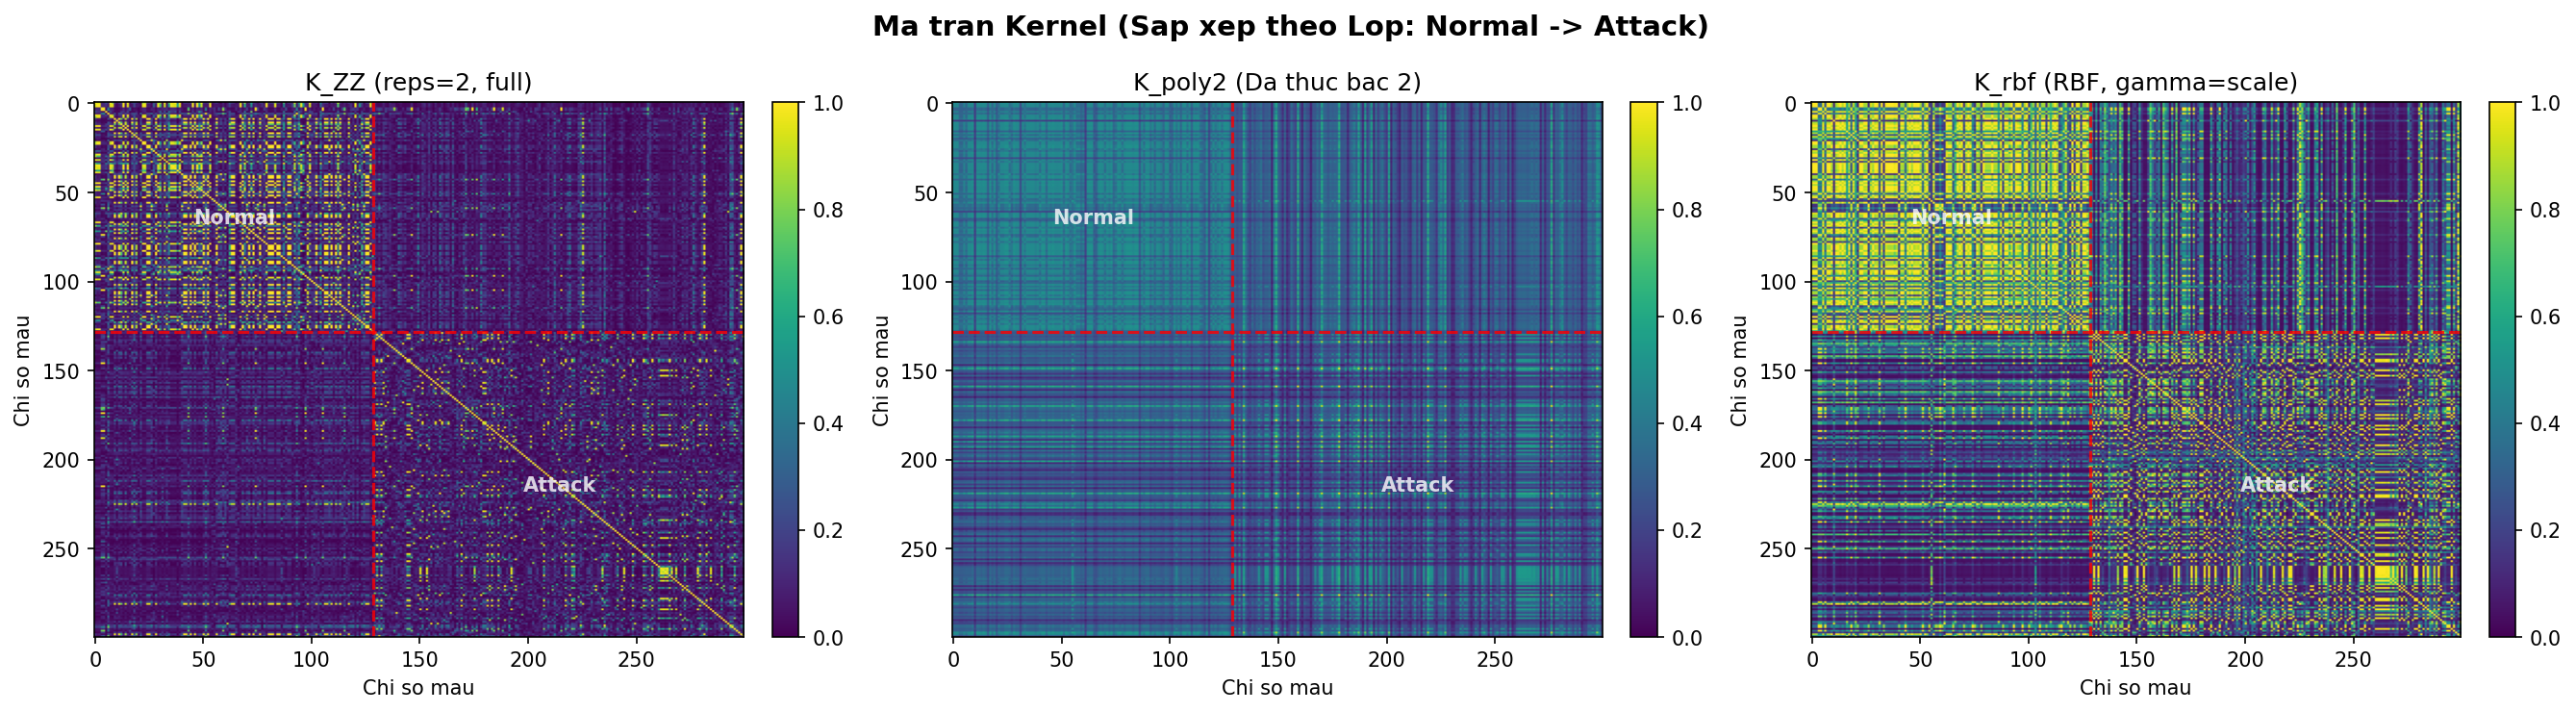


Phan tich block ratio (gia tri trung binh trong lop / khac lop):
Kernel                   Within     Across      Ratio
------------------------------------------------------
K_ZZ                     0.1820     0.0949       1.92x
K_poly2                  0.3078     0.2844       1.08x
K_RBF                    0.4373     0.2591       1.69x


In [16]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Ma tran Kernel (Sap xep theo Lop: Normal -> Attack)", fontsize=14, fontweight='bold')

# Danh sach kernel de ve
kernels = [
    (K_quantum, f"K_ZZ (reps={ZZ_REPS_TARGET}, full)"),
    (K_poly2,   "K_poly2 (Da thuc bac 2)"),
    (K_rbf,     "K_rbf (RBF, gamma=scale)"),
]

for ax, (K, title) in zip(axes, kernels):
    im = ax.imshow(K, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    # Duong phan tach giua khoi Normal va Attack
    ax.axhline(n_normal - 0.5, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.axvline(n_normal - 0.5, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Chi so mau")
    ax.set_ylabel("Chi so mau")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Chu thich vung khoi
    ax.text(n_normal/2, n_normal/2, "Normal",
            ha='center', va='center', color='white', fontsize=10, alpha=0.8, fontweight='bold')
    ax.text(n_normal + (N_SUBSAMPLE - n_normal)/2, n_normal + (N_SUBSAMPLE - n_normal)/2, "Attack",
            ha='center', va='center', color='white', fontsize=10, alpha=0.8, fontweight='bold')

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "c2_kernel_heatmaps.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"Da luu: {out_path}")
display(Image(filename=out_path))
# plt.show()
# Thong ke cau truc khoi (ty le trong lop / khac lop)
print("\nPhan tich block ratio (gia tri trung binh trong lop / khac lop):")
print(f"{'Kernel':<20} {'Within':>10} {'Across':>10} {'Ratio':>10}")
print("-" * 54)
for K, name in [(K_quantum, "K_ZZ"), (K_poly2, "K_poly2"), (K_rbf, "K_RBF")]:
    w, a, r = block_ratio(K, n_normal)
    print(f"{name:<20} {w:>10.4f} {a:>10.4f} {r:>10.2f}x")

## 5. Đánh giá Centered Kernel Alignment (CKA) và Kiểm định H2
* **Tính toán CKA:** Đo lường điểm số CKA giữa các kernel ($K_{ZZ}$, $K_{\text{poly2}}$, $K_{\text{RBF}}$) và Ideal Label Kernel, kết hợp khoảng tin cậy bootstrap 95% nhằm đảm bảo ý nghĩa thống kê.
* **Kiểm định Giả thuyết (H2):** Kiểm tra trực tiếp giả thuyết $CKA(K_{ZZ}) > CKA(K_{\text{poly2}})$, qua đó chứng minh Quantum Kernel bắt giữ cấu trúc phân lớp vượt trội hơn so với đa thức bậc 2 cổ điển.
* **Trực quan hóa:** Vẽ và lưu biểu đồ cột so sánh điểm CKA kèm thanh sai số (error bars) để làm minh chứng vững chắc cho báo cáo nghiên cứu.

Dang tinh gia tri CKA voi khoang tin cay bootstrap (N_bootstrap=200)...
  CKA(K_ZZ,    K_ideal) = 0.2701  95% CI [0.2359, 0.3192]
  CKA(K_poly2, K_ideal) = 0.3945  95% CI [0.3388, 0.4640]
  CKA(K_RBF,   K_ideal) = 0.3838  95% CI [0.3265, 0.4535]

  H2 KHONG DUOC XAC NHAN: CKA(K_ZZ) <= CKA(K_poly2)
Da luu: ../reports\c2_cka_comparison.png


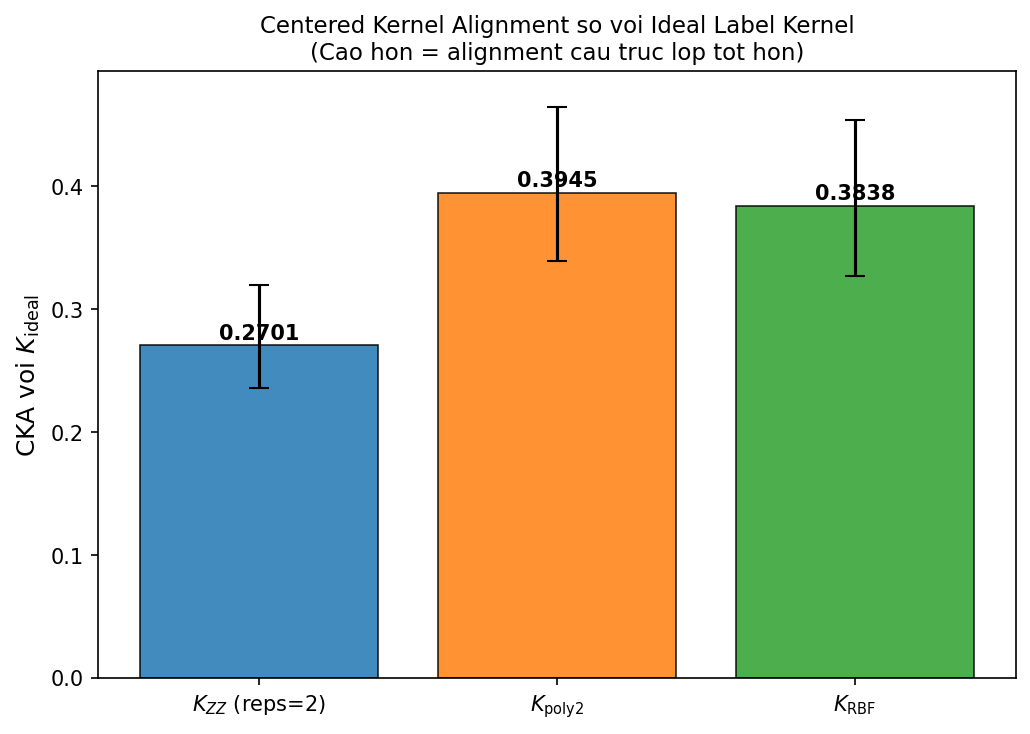

In [17]:
print("Dang tinh gia tri CKA voi khoang tin cay bootstrap (N_bootstrap={})...".format(N_BOOTSTRAP))

cka_q, lo_q, hi_q = cka_with_ci(K_quantum, K_ideal)
cka_p, lo_p, hi_p = cka_with_ci(K_poly2,   K_ideal)
cka_r, lo_r, hi_r = cka_with_ci(K_rbf,     K_ideal)

print(f"  CKA(K_ZZ,    K_ideal) = {cka_q:.4f}  95% CI [{lo_q:.4f}, {hi_q:.4f}]")
print(f"  CKA(K_poly2, K_ideal) = {cka_p:.4f}  95% CI [{lo_p:.4f}, {hi_p:.4f}]")
print(f"  CKA(K_RBF,   K_ideal) = {cka_r:.4f}  95% CI [{lo_r:.4f}, {hi_r:.4f}]")

# Kiem dinh H2
h2_supported = cka_q > cka_p
print(f"\n  H2 {'DUOC XAC NHAN' if h2_supported else 'KHONG DUOC XAC NHAN'}: CKA(K_ZZ) {'>' if h2_supported else '<='} CKA(K_poly2)")

# Ve bieu do so sanh
fig, ax = plt.subplots(figsize=(7, 5))
labels  = ["$K_{ZZ}$ (reps=2)", "$K_{\\text{poly2}}$", "$K_{\\text{RBF}}$"]
vals    = [cka_q, cka_p, cka_r]
los     = [lo_q,  lo_p,  lo_r]
his     = [hi_q,  hi_p,  hi_r]
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
yerrs   = [[v - l for v, l in zip(vals, los)],
           [h - v for v, h in zip(vals, his)]]

bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax.errorbar(labels, vals, yerr=yerrs, fmt='none', color='black', capsize=5, linewidth=1.5)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.4f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel("CKA voi $K_{\\text{ideal}}$", fontsize=12)
ax.set_title("Centered Kernel Alignment so voi Ideal Label Kernel\n"
             "(Cao hon = alignment cau truc lop tot hon)", fontsize=11)
ax.set_ylim(0, max(vals) * 1.25)
ax.axhline(0, color='black', linewidth=0.5)

if h2_supported:
    ax.annotate("H2 ok", xy=(0, cka_q), xytext=(0.5, cka_q + 0.01),
                fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "c2_cka_comparison.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Da luu: {out_path}")
display(Image(filename=out_path))

## 6. Phân Tích Eigenspectrum và Effective Rank
Đi sâu vào phân tích phổ giá trị kỳ dị (Eigenspectrum) để đo lường mức độ phong phú của không gian đặc trưng do mỗi kernel sinh ra:
* **Tính toán Effective Rank (Hạng hiệu dụng):** Đánh giá hạng hiệu dụng của các ma trận kernel kèm khoảng tin cậy 95% Bootstrap. Chỉ số này càng cao chứng tỏ không gian đặc trưng được sử dụng càng đa dạng và chứa nhiều thông tin.
* **Trực quan hóa Phổ kỳ dị:** Vẽ biểu đồ khối lượng tích lũy và phổ logarit (Log Spectrum) của các giá trị kỳ dị. Biểu đồ này giúp trực quan hóa tốc độ suy giảm thông tin; suy giảm càng chậm thì khả năng biểu diễn (expressivity) của kernel đó càng mạnh.

Da luu: ../reports\c2_eigenspectrum.png


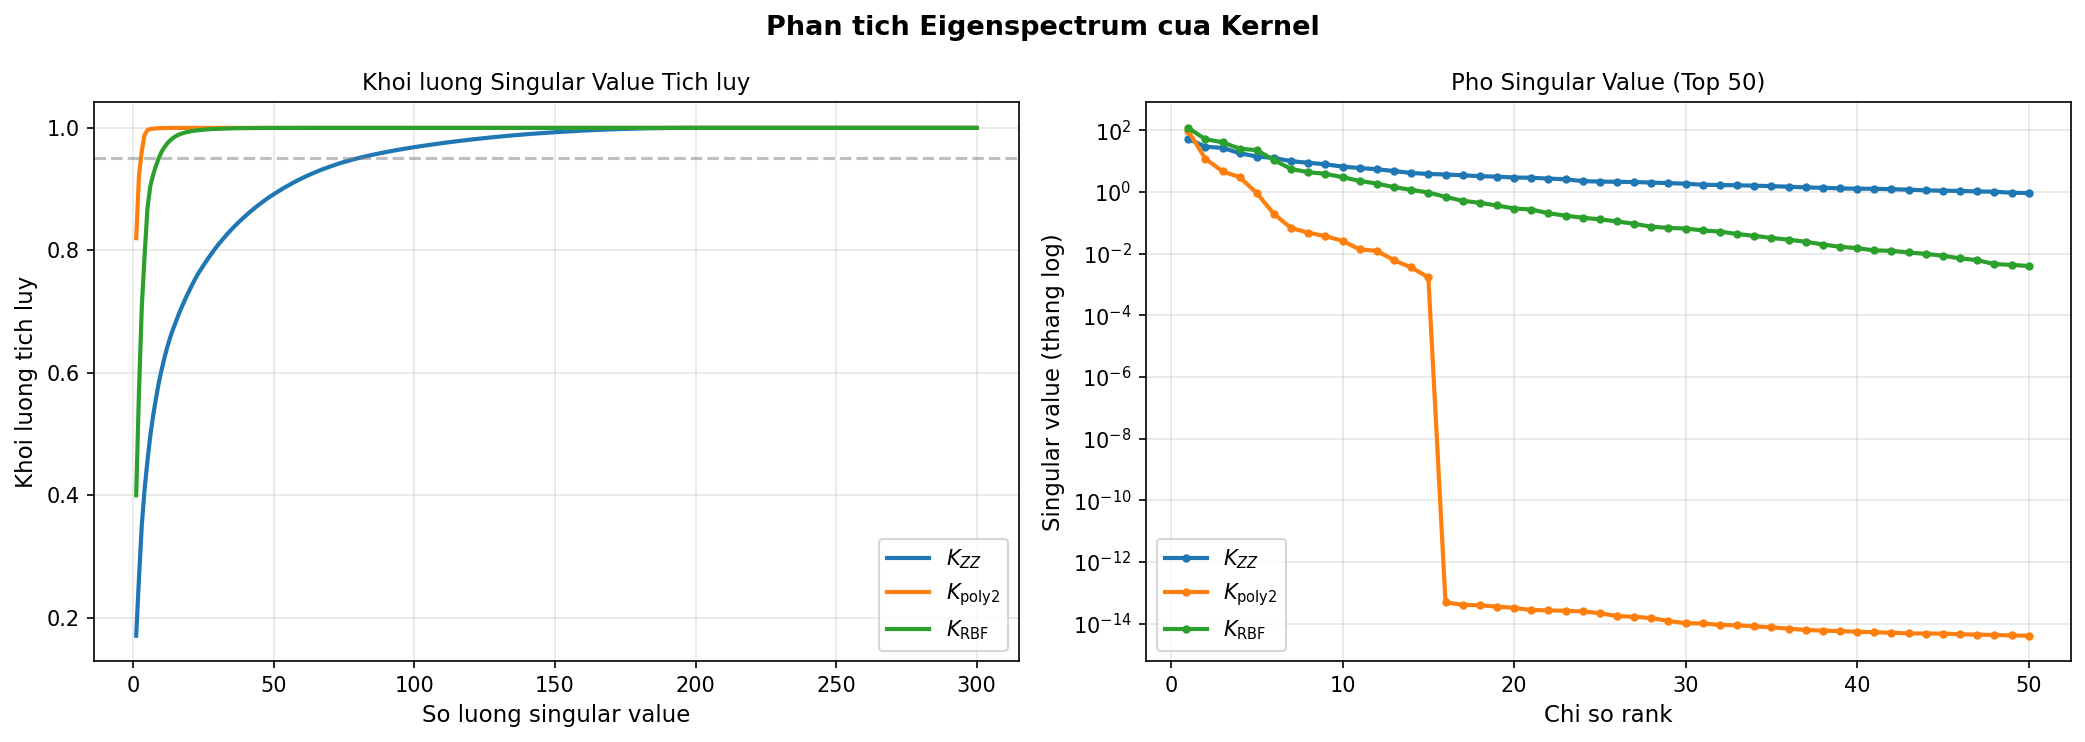

### Phân tích Effective Rank (Phạm vi: [1, 300])

Công thức: $ER = \frac{(\sum \sigma_i)^2}{\sum \sigma_i^2}$

,Kernel,Effective Rank,95% CI Lower,95% CI Upper
0,$K_{ZZ}$,17.10,13.89,19.11
1,$K_{\text{poly2}}$,1.46,1.42,1.50
2,$K_{\text{RBF}}$,4.48,4.06,4.80


> **Nhận xét:** Effective rank càng cao, không gian đặc trưng (feature space) được sử dụng càng phong phú[cite: 97].

In [22]:
from IPython.display import display, Markdown

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phan tich Eigenspectrum cua Kernel", fontsize=13, fontweight='bold')

kernels_named = [
    (K_quantum, "$K_{ZZ}$",         '#1f77b4'),
    (K_poly2,   "$K_{\\text{poly2}}$", '#ff7f0e'),
    (K_rbf,     "$K_{\\text{RBF}}$",   '#2ca02c'),
]

eff_ranks = {}
for K, name, color in kernels_named:
    sigmas = np.linalg.svd(K, compute_uv=False)
    sigmas_pos = sigmas[sigmas > 1e-12]

    # Effective rank voi khoang tin cay bootstrap
    er = effective_rank(K)
    lo_er, hi_er = bootstrap_ci(effective_rank, K, n_bootstrap=N_BOOTSTRAP)
    eff_ranks[name] = (er, lo_er, hi_er)

    # Khoi luong tich luy singular value
    cumsum = np.cumsum(sigmas) / sigmas.sum()
    ax1.plot(np.arange(1, len(cumsum)+1), cumsum, label=name, color=color, linewidth=2)

    # Pho log singular value (top 50)
    top_n = min(50, len(sigmas))
    ax2.semilogy(np.arange(1, top_n+1), sigmas[:top_n], label=name, color=color,
                 linewidth=2, marker='o', markersize=3)

ax1.set_xlabel("So luong singular value", fontsize=11)
ax1.set_ylabel("Khoi luong tich luy", fontsize=11)
ax1.set_title("Khoi luong Singular Value Tich luy", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axhline(0.95, color='gray', linestyle='--', alpha=0.5, label='95% mass')

ax2.set_xlabel("Chi so rank", fontsize=11)
ax2.set_ylabel("Singular value (thang log)", fontsize=11)
ax2.set_title("Pho Singular Value (Top 50)", fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "c2_eigenspectrum.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Da luu: {out_path}")
display(Image(filename=out_path))

data_list = []
for name, (er, lo, hi) in eff_ranks.items():
    data_list.append({
        "Kernel": name,
        "Effective Rank": f"{er:.2f}",
        "95% CI Lower": f"{lo:.2f}",
        "95% CI Upper": f"{hi:.2f}"
    })

df_er = pd.DataFrame(data_list)

display(Markdown(f"### Phân tích Effective Rank (Phạm vi: [1, {N_SUBSAMPLE}])"))
display(Markdown(r"Công thức: $ER = \frac{(\sum \sigma_i)^2}{\sum \sigma_i^2}$"))

display(df_er)

display(Markdown("> **Nhận xét:** Effective rank càng cao, không gian đặc trưng (feature space) được sử dụng càng phong phú[cite: 97]."))

## 7. Phân Tích Expressibility (Khả năng Biểu diễn)
Đánh giá khả năng biểu diễn của mạch lượng tử dựa trên phương pháp của Sim et al. (2019), nhằm đo lường mức độ phong phú của không gian trạng thái lượng tử được tạo ra:
* **Tính toán KL Divergence ($D_{KL}$):** Lấy mẫu ngẫu nhiên và so sánh phân phối độ trung thực (fidelity) của ZZFeatureMap với phân phối Haar-random lý tưởng (đại diện cho không gian lượng tử phân bố đều). Giá trị $D_{KL}$ càng nhỏ chứng tỏ mạch càng có sức mạnh biểu diễn cao.
* **Kiểm định Giả thuyết (H4):** Kiểm tra tính đơn điệu khi thay đổi độ sâu mạch (`reps` = 1, 2, 3). Giả thuyết kỳ vọng rằng khi tăng số vòng lặp `reps`, $D_{KL}$ sẽ giảm dần (mạch tiệm cận với phân phối ngẫu nhiên lý tưởng hơn).
* **Trực quan hóa:** Vẽ các biểu đồ histogram đối chiếu trực tiếp phân phối của mạch ZZFeatureMap ở các mức `reps` khác nhau với đường cong lý tưởng của phân phối Haar (Beta(1, 15)).

Lay mau 2000 cap ngau nhien cho moi cau hinh reps...
  reps=1... D_KL = 0.0261  (12.9s)
  reps=2... D_KL = 0.0156  (17.6s)
  reps=3... D_KL = 0.0422  (27.6s)

Expressibility (D_KL tu Haar; thap hon = bieu dien phong phu hon):
  reps=1: D_KL = 0.0261
  reps=2: D_KL = 0.0156
  reps=3: D_KL = 0.0422

  H4 tinh don dieu KHONG DON DIEU NGHIEM NGAT
  -> Tang N_EXPR_PAIRS len 5000 de co uoc luong dang tin cay hon
Da luu: ../reports\c2_expressibility.png


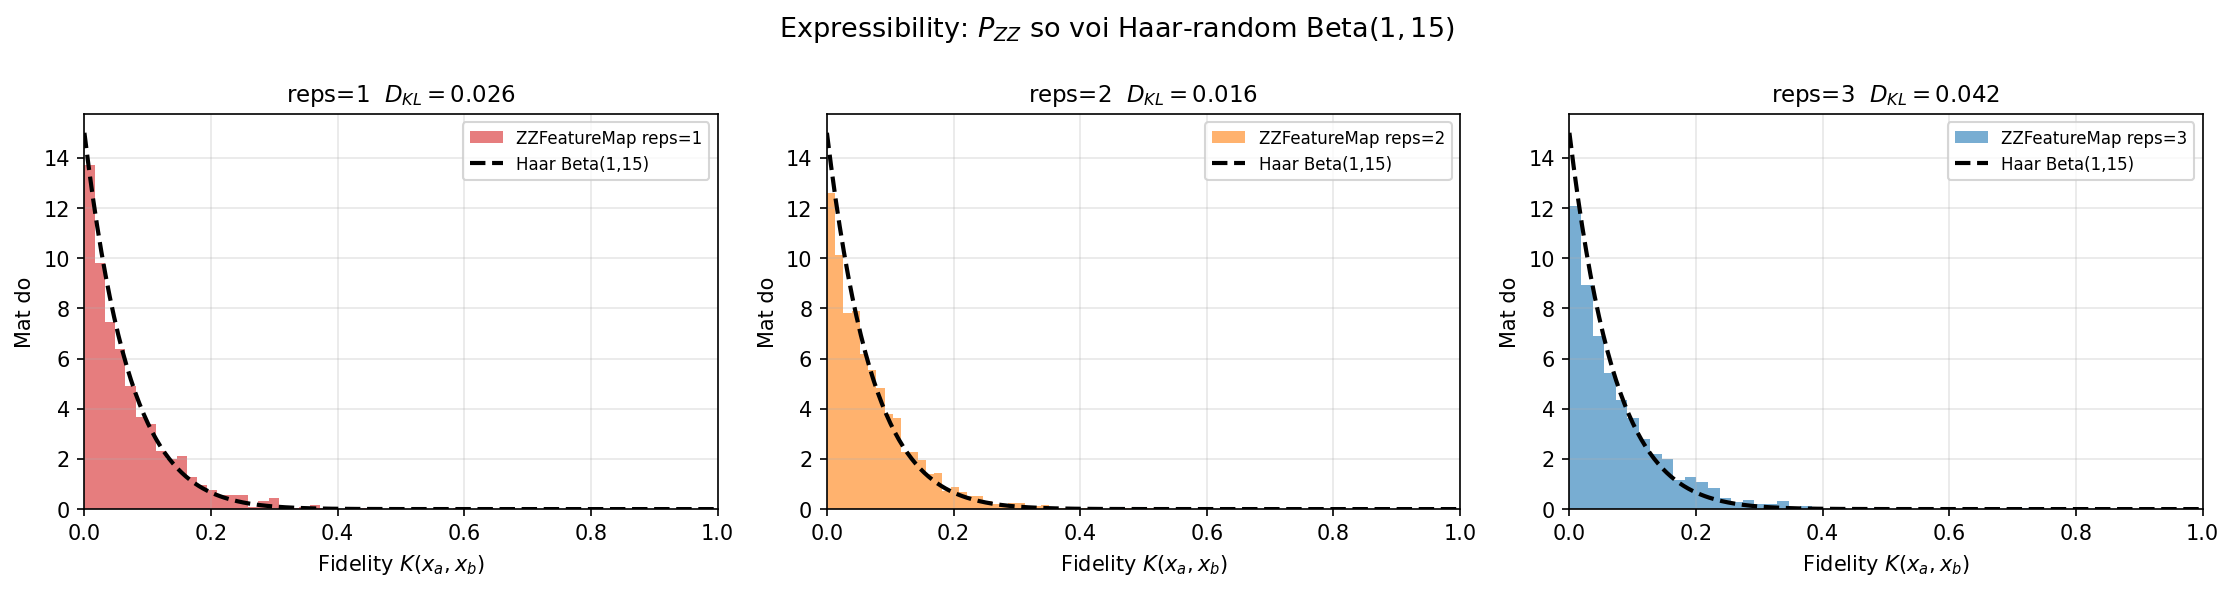

In [24]:
rng = np.random.RandomState(RANDOM_STATE)
reps_list  = [1, 2, 3]
kl_values  = {}
fidelities_all = {}

print(f"Lay mau {N_EXPR_PAIRS} cap ngau nhien cho moi cau hinh reps...")
for reps in reps_list:
    print(f"  reps={reps}...", end=" ", flush=True)
    t0 = time.time()

    # Lay mau cap ngau nhien tu [0, pi]^4
    X_a = rng.uniform(0, np.pi, size=(N_EXPR_PAIRS, N_QUBITS)).astype(np.float32)
    X_b = rng.uniform(0, np.pi, size=(N_EXPR_PAIRS, N_QUBITS)).astype(np.float32)

    # Tinh fidelity duong cheo: K(x_a[i], x_b[i]) — tranh chi phi O(N^2)
    # evaluate(X, Y) tra ve cross-kernel; can diag(K(X_a, X_b))
    qk_expr = build_quantum_kernel_cfg(reps=reps, entanglement="full")
    fids = np.zeros(N_EXPR_PAIRS)
    for i in range(N_EXPR_PAIRS):
        fids[i] = qk_expr.evaluate(X_a[i:i+1], X_b[i:i+1])[0, 0]

    fidelities_all[reps] = fids
    kl = kl_divergence_from_haar(fids, n_qubits=N_QUBITS, n_bins=50)
    kl_values[reps] = kl
    dt = time.time() - t0
    print(f"D_KL = {kl:.4f}  ({dt:.1f}s)")

# Kiem tra tinh don dieu ky vong cua H4
print("\nExpressibility (D_KL tu Haar; thap hon = bieu dien phong phu hon):")
for reps in reps_list:
    print(f"  reps={reps}: D_KL = {kl_values[reps]:.4f}")

h4_supported = kl_values[1] >= kl_values[2] and kl_values[2] >= kl_values[3]
print(f"\n  H4 tinh don dieu {'DUOC XAC NHAN' if h4_supported else 'KHONG DON DIEU NGHIEM NGAT'}")
if not h4_supported:
    print("  -> Tang N_EXPR_PAIRS len 5000 de co uoc luong dang tin cay hon")

# Ve bieu do
N_haar = 2**N_QUBITS - 1
haar_x = np.linspace(0, 1, 300)
haar_y = beta_dist.pdf(haar_x, a=1, b=N_haar)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(r"Expressibility: $P_{ZZ}$ so voi Haar-random $\text{Beta}(1,15)$", fontsize=13)

colors_reps = {1: '#d62728', 2: '#ff7f0e', 3: '#1f77b4'}
for ax, reps in zip(axes, reps_list):
    fids = fidelities_all[reps]
    ax.hist(fids, bins=40, density=True, alpha=0.6, color=colors_reps[reps],
            label=f"ZZFeatureMap reps={reps}")
    ax.plot(haar_x, haar_y, 'k--', linewidth=2, label="Haar Beta(1,15)")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Fidelity $K(x_a, x_b)$", fontsize=10)
    ax.set_ylabel("Mat do", fontsize=10)
    ax.set_title(f"reps={reps}  $D_{{KL}}={kl_values[reps]:.3f}$", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "c2_expressibility.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Da luu: {out_path}")
display(Image(filename=out_path))

## 8. Phân Tích Entanglement Entropy và Kiểm định H3
Đi sâu vào bản chất lượng tử của mô hình bằng cách đo lường Entanglement Entropy (Von Neumann), giúp củng cố trực tiếp cho Đóng góp 2 về khả năng biểu diễn và phân tách đặc trưng của mạch:
* **Tính toán Entropy:** Đo lường mức độ vướng víu lượng tử giữa hai phần của mạch (bipartition `{0,1} | {2,3}`) cho từng điểm dữ liệu.
* **Kiểm định Thống kê (H3):** Áp dụng kiểm định phi tham số Mann-Whitney U để xác minh giả thuyết: các mẫu tấn công (Attack) kích hoạt mức độ vướng víu lượng tử cao hơn so với lưu lượng mạng bình thường (Normal).
* **Trực quan hóa Phân phối:** Sử dụng biểu đồ Violin và Kernel Density Estimation (KDE) để biểu diễn trực quan sự khác biệt về phân bố entropy giữa hai lớp, làm nổi bật lợi thế biểu diễn phi tuyến của Quantum Kernel.

Dang tinh entanglement entropy cho 300 mau...
  Bipartition: {0,1} | {2,3},  reps=2, entanglement='full'
  50/300 da xu ly
  100/300 da xu ly
  150/300 da xu ly
  200/300 da xu ly
  250/300 da xu ly
  300/300 da xu ly

Thong ke Entanglement Entropy:
  Normal: mean=0.7497, std=0.3763, pham vi=[0.1316,1.7346]
  Attack: mean=1.2145, std=0.2695, pham vi=[0.4511,1.8581]
  Tat ca gia tri trong [0,2] bit: True

Kiem dinh Mann-Whitney U (H3: entropy attack > entropy normal):
  U=18207.5, p=0.000000  -> H3 DUOC XAC NHAN tai alpha=0.05
Da luu: ../reports\c2_entanglement_entropy.png


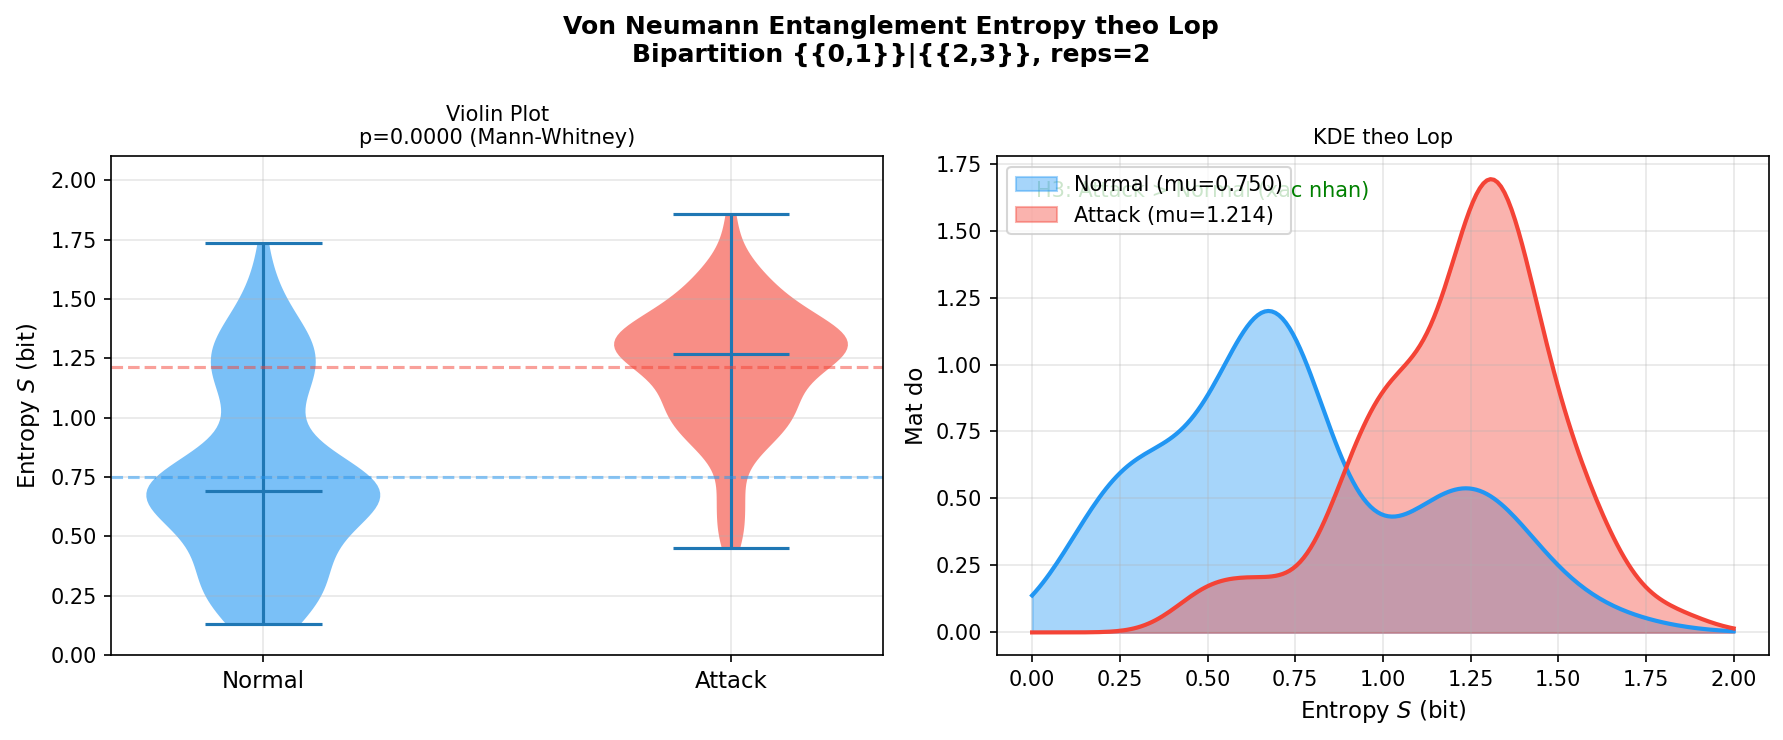

In [25]:
print(f"Dang tinh entanglement entropy cho {N_SUBSAMPLE} mau...")
print(f"  Bipartition: {{0,1}} | {{2,3}},  reps={ZZ_REPS_TARGET}, entanglement={ZZ_ENTANGLEMENT_TARGET!r}")

entropies = []
for i, x in enumerate(X_c2_sorted):
    s = compute_entanglement_entropy(x, reps=ZZ_REPS_TARGET, entanglement=ZZ_ENTANGLEMENT_TARGET)
    entropies.append(s)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{N_SUBSAMPLE} da xu ly")

entropies = np.array(entropies)

# Tach entropy theo lop (Normal dung truoc trong X_c2_sorted)
S_normal = entropies[:n_normal]
S_attack = entropies[n_normal:]

print(f"\nThong ke Entanglement Entropy:")
print(f"  Normal: mean={S_normal.mean():.4f}, std={S_normal.std():.4f}, pham vi=[{S_normal.min():.4f},{S_normal.max():.4f}]")
print(f"  Attack: mean={S_attack.mean():.4f}, std={S_attack.std():.4f}, pham vi=[{S_attack.min():.4f},{S_attack.max():.4f}]")
print(f"  Tat ca gia tri trong [0,2] bit: {(entropies >= 0).all() and (entropies <= 2.0 + 1e-6).all()}")

# Kiem dinh Mann-Whitney U (H3)
mw_stat, mw_pval = mannwhitneyu(S_attack, S_normal, alternative='greater')
h3_supported = mw_pval < 0.05
print(f"\nKiem dinh Mann-Whitney U (H3: entropy attack > entropy normal):")
print(f"  U={mw_stat:.1f}, p={mw_pval:.6f}  -> H3 {'DUOC XAC NHAN' if h3_supported else 'KHONG DUOC XAC NHAN'} tai alpha=0.05")

# Ve bieu do: violin + KDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Von Neumann Entanglement Entropy theo Lop\n"
             f"Bipartition {{{{0,1}}}}|{{{{2,3}}}}, reps={ZZ_REPS_TARGET}",
             fontsize=12, fontweight='bold')

# Violin plot
data_violin = [S_normal, S_attack]
vp = ax1.violinplot(data_violin, positions=[0, 1], showmedians=True, showextrema=True)
for body in vp['bodies']:
    body.set_alpha(0.6)
vp['bodies'][0].set_facecolor('#2196F3')
vp['bodies'][1].set_facecolor('#F44336')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Normal', 'Attack'], fontsize=11)
ax1.set_ylabel("Entropy $S$ (bit)", fontsize=11)
ax1.set_title(f"Violin Plot\np={mw_pval:.4f} (Mann-Whitney)", fontsize=10)
ax1.axhline(S_normal.mean(), color='#2196F3', linestyle='--', alpha=0.5)
ax1.axhline(S_attack.mean(), color='#F44336', linestyle='--', alpha=0.5)
ax1.set_ylim(0, 2.1)
ax1.grid(True, alpha=0.3)

# KDE plot
from scipy.stats import gaussian_kde
s_range = np.linspace(0, 2, 200)
kde_normal = gaussian_kde(S_normal, bw_method='scott')(s_range)
kde_attack = gaussian_kde(S_attack, bw_method='scott')(s_range)
ax2.fill_between(s_range, kde_normal, alpha=0.4, color='#2196F3', label=f"Normal (mu={S_normal.mean():.3f})")
ax2.fill_between(s_range, kde_attack, alpha=0.4, color='#F44336', label=f"Attack (mu={S_attack.mean():.3f})")
ax2.plot(s_range, kde_normal, color='#2196F3', linewidth=2)
ax2.plot(s_range, kde_attack, color='#F44336', linewidth=2)
ax2.set_xlabel("Entropy $S$ (bit)", fontsize=11)
ax2.set_ylabel("Mat do", fontsize=11)
ax2.set_title("KDE theo Lop", fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

h3_text = "H3: Attack > Normal (xac nhan)" if h3_supported else "H3: Khong co y nghia thong ke"
ax2.text(0.05, 0.95, h3_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='top',
         color='green' if h3_supported else 'red')

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "c2_entanglement_entropy.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Da luu: {out_path}")
display(Image(filename=out_path))

## 9. Phân Tích Kernel Concentration
Đánh giá hiện tượng suy giảm thông tin (Kernel Concentration) theo lý thuyết của Thanasilp et al. (2022), nhằm đảm bảo không gian đặc trưng lượng tử không bị "phẳng hóa" khi thay đổi cấu hình mạch:
* **Quét tham số độ sâu (reps):** Thử nghiệm mạch lượng tử với số vòng lặp `reps` từ 1 đến 5 trên tập dữ liệu mẫu.
* **Đánh giá thống kê hạt nhân:** Đo lường giá trị trung bình và phương sai của các phần tử nằm ngoài đường chéo chính (off-diagonal) trong ma trận kernel để kiểm tra mức độ suy giảm.
* **Xác nhận vùng khả thi (Informative Regime):** Trực quan hóa mối tương quan giữa Effective Rank và `reps` để chứng minh rằng với 4 qubit, cấu hình mục tiêu `reps=2` vẫn giữ được sức mạnh biểu diễn tốt và không bị rơi vào trạng thái mất thông tin.

Quet concentration (reps 1-5) tren subsample N_CONC=150...
  reps=1... mean=0.1194, var=0.040466, eff_rank=16.9  (44.9s)
  reps=2... mean=0.1327, var=0.036702, eff_rank=17.0  (76.7s)
  reps=3... mean=0.1238, var=0.033291, eff_rank=18.7  (110.8s)
  reps=4... mean=0.1145, var=0.029336, eff_rank=20.9  (124.7s)
  reps=5... mean=0.1210, var=0.028043, eff_rank=20.8  (154.5s)

Tinh don dieu concentration:
  Trung binh ngoai duong cheo: {1: np.float64(0.1194), 2: np.float64(0.1327), 3: np.float64(0.1238), 4: np.float64(0.1145), 5: np.float64(0.121)}
  H4 canh bao: mean(reps=1) < mean(reps=2)  (suy giam nhe duoc ky vong voi n=4 qubit)
  Luu y: Nguong concentration xuat hien o reps cao hon nhieu voi he thong qubit nho
         (Thanasilp et al., 2022) — n=4 an toan trong che do informative.
Da luu: ../reports\c2_concentration.png


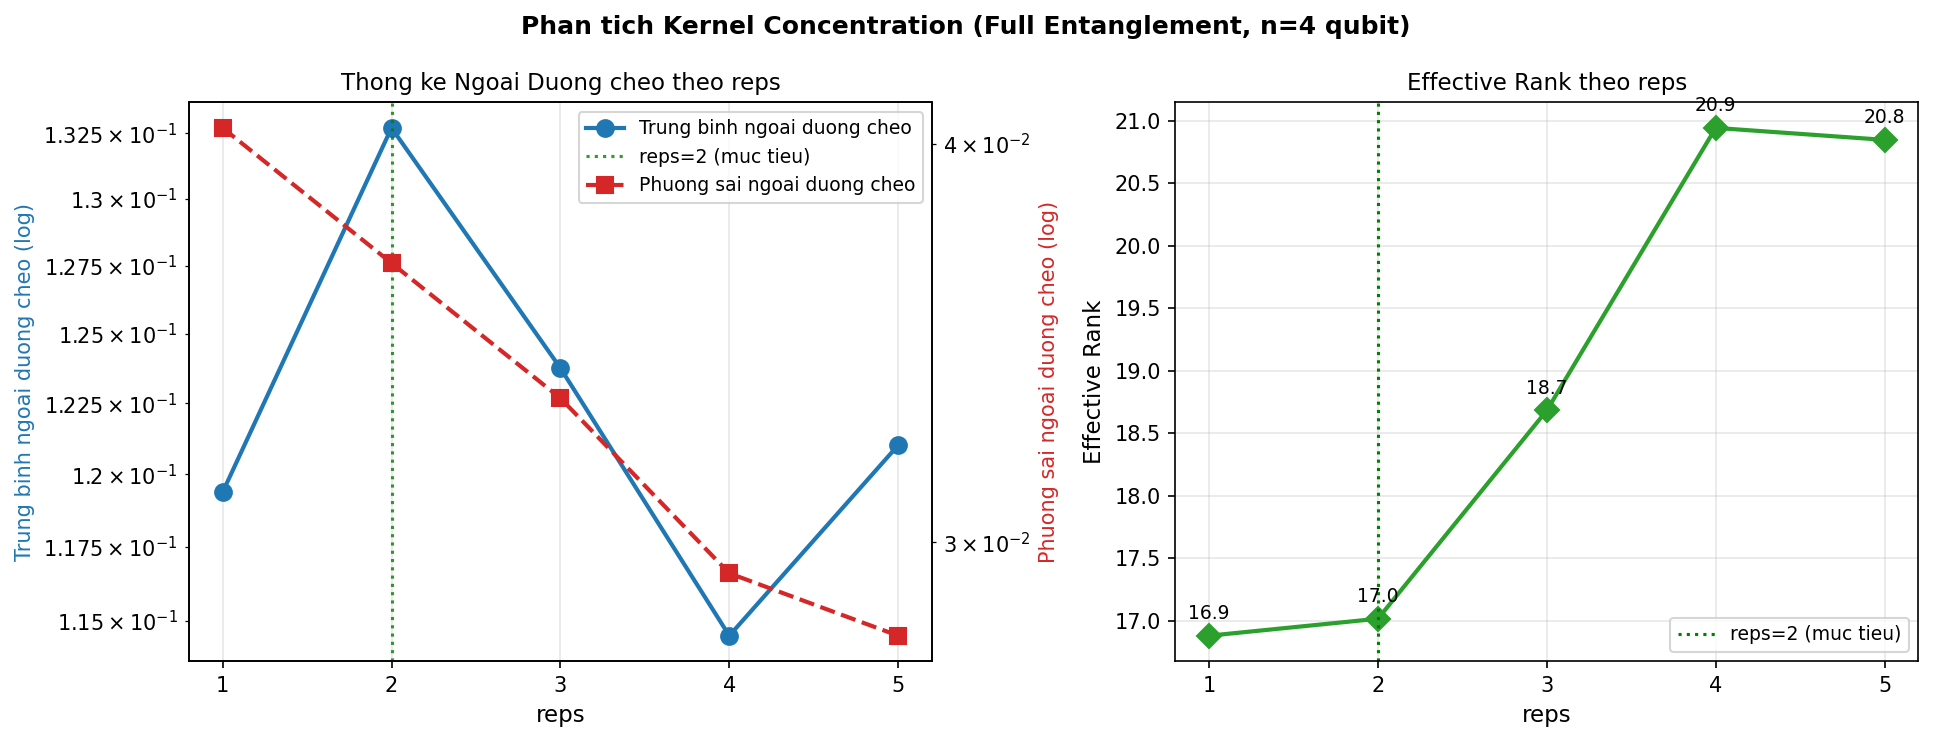

In [27]:
# Dung subsample nho hon cho vong quet 5 reps
X_conc, y_conc = stratified_subsample(X_test_full, y_test_full, N_CONC)

reps_sweep  = [1, 2, 3, 4, 5]
mean_offdiag = []
var_offdiag  = []
eff_rank_sweep = []

print(f"Quet concentration (reps 1-5) tren subsample N_CONC={N_CONC}...")
for reps in reps_sweep:
    print(f"  reps={reps}...", end=" ", flush=True)
    t0 = time.time()
    qk = build_quantum_kernel_cfg(reps=reps, entanglement="full")
    K_s = qk.evaluate(X_conc)

    # Mat na ngoai duong cheo (loai duong cheo — luon la 1.0)
    mask = ~np.eye(N_CONC, dtype=bool)
    od_vals = K_s[mask]

    mean_offdiag.append(float(od_vals.mean()))
    var_offdiag.append(float(od_vals.var()))
    eff_rank_sweep.append(effective_rank(K_s))

    dt = time.time() - t0
    print(f"mean={od_vals.mean():.4f}, var={od_vals.var():.6f}, eff_rank={eff_rank_sweep[-1]:.1f}  ({dt:.1f}s)")

mean_offdiag  = np.array(mean_offdiag)
var_offdiag   = np.array(var_offdiag)
eff_rank_sweep = np.array(eff_rank_sweep)

# Kiem tra H4: suy giam don dieu nhe (khong phai concentration tham khoc)
print(f"\nTinh don dieu concentration:")
print(f"  Trung binh ngoai duong cheo: {dict(zip(reps_sweep, mean_offdiag.round(4)))}")
h4_conc = mean_offdiag[0] >= mean_offdiag[2]  # reps=1 >= reps=2

# ĐÃ SỬA LỖI TẠI DÒNG NÀY (Bỏ dấu nháy dư ở '>=')
print(f"  H4 {'ok' if h4_conc else 'canh bao'}: mean(reps=1) {'>=' if h4_conc else '<'} mean(reps=2)  "
      f"(suy giam nhe duoc ky vong voi n=4 qubit)")
print("  Luu y: Nguong concentration xuat hien o reps cao hon nhieu voi he thong qubit nho")
print("         (Thanasilp et al., 2022) — n=4 an toan trong che do informative.")

# Ve bieu do
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Phan tich Kernel Concentration (Full Entanglement, n=4 qubit)",
             fontsize=12, fontweight='bold')

color_mean = '#1f77b4'
color_var  = '#d62728'
color_er   = '#2ca02c'

ax1_twin = ax1.twinx()
ax1.semilogy(reps_sweep, mean_offdiag, 'o-', color=color_mean, linewidth=2,
             markersize=8, label="Trung binh ngoai duong cheo")
ax1_twin.semilogy(reps_sweep, var_offdiag, 's--', color=color_var, linewidth=2,
                  markersize=8, label="Phuong sai ngoai duong cheo")
ax1.axvline(ZZ_REPS_TARGET, color='green', linewidth=1.5, linestyle=':', alpha=0.8,
            label=f"reps={ZZ_REPS_TARGET} (muc tieu)")
ax1.set_xlabel("reps", fontsize=11)
ax1.set_ylabel("Trung binh ngoai duong cheo (log)", fontsize=10, color=color_mean)
ax1_twin.set_ylabel("Phuong sai ngoai duong cheo (log)", fontsize=10, color=color_var)
ax1.set_title("Thong ke Ngoai Duong cheo theo reps", fontsize=11)
ax1.set_xticks(reps_sweep)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(reps_sweep, eff_rank_sweep, 'D-', color=color_er, linewidth=2, markersize=8)
ax2.axvline(ZZ_REPS_TARGET, color='green', linewidth=1.5, linestyle=':',
            label=f"reps={ZZ_REPS_TARGET} (muc tieu)")
ax2.set_xlabel("reps", fontsize=11)
ax2.set_ylabel("Effective Rank", fontsize=11)
ax2.set_title("Effective Rank theo reps", fontsize=11)
ax2.set_xticks(reps_sweep)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
for r, er in zip(reps_sweep, eff_rank_sweep):
    ax2.annotate(f"{er:.1f}", (r, er), textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=9)

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "c2_concentration.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Da luu: {out_path}")
display(Image(filename=out_path))

## 10. So Sánh Biên Quyết Định và Hiệu Suất (QSVM vs. Classical SVM)
Thực nghiệm trực tiếp khả năng biểu diễn của Quantum Kernel (Contribution 2) bằng cách so sánh hiệu suất phân lớp với các mô hình SVM truyền thống:
* **Huấn luyện & So sánh:** Xây dựng và đánh giá đồng thời QSVM (dùng $K_{ZZ}$), Classical SVM (Poly-2) và Classical SVM (RBF) trên cùng một tập mẫu nhỏ để kiểm tra khả năng học (learning capability).
* **Phân tích Margin:** Ước lượng xấp xỉ độ rộng biên quyết định (margin proxy) dựa trên các hệ số dual. Bước này nhằm chứng minh không gian lượng tử giúp tạo ra mặt phẳng siêu phân cách rộng và rõ ràng hơn. 
* **Trực quan hóa Hiệu suất:** Thống kê và vẽ biểu đồ các chỉ số đánh giá cốt lõi (Accuracy, Recall, Precision, F1-score), cung cấp minh chứng định lượng cho lợi thế biểu diễn phi tuyến của mạch lượng tử.

Dang huan luyen cac bo phan loai SVM...
  Dang tinh K_train va K_test cho QSVM... 918.3s
  Dang huan luyen CSVM poly-2... xong
  Dang huan luyen CSVM RBF... xong

Ket qua phan loai (N_train=300, N_test=300):
  QSVM (K_ZZ)         : Acc=0.8233, Rec=0.7018, Pre=0.9836, F1=0.8191
  CSVM poly-2         : Acc=0.7233, Rec=0.5205, Pre=0.9889, F1=0.6820
  CSVM RBF            : Acc=0.7167, Rec=0.5088, Pre=0.9886, F1=0.6718

Uoc luong margin (2/||w||): QSVM=0.2588

Da luu: ../reports\c2_decision_boundary_comparison.png


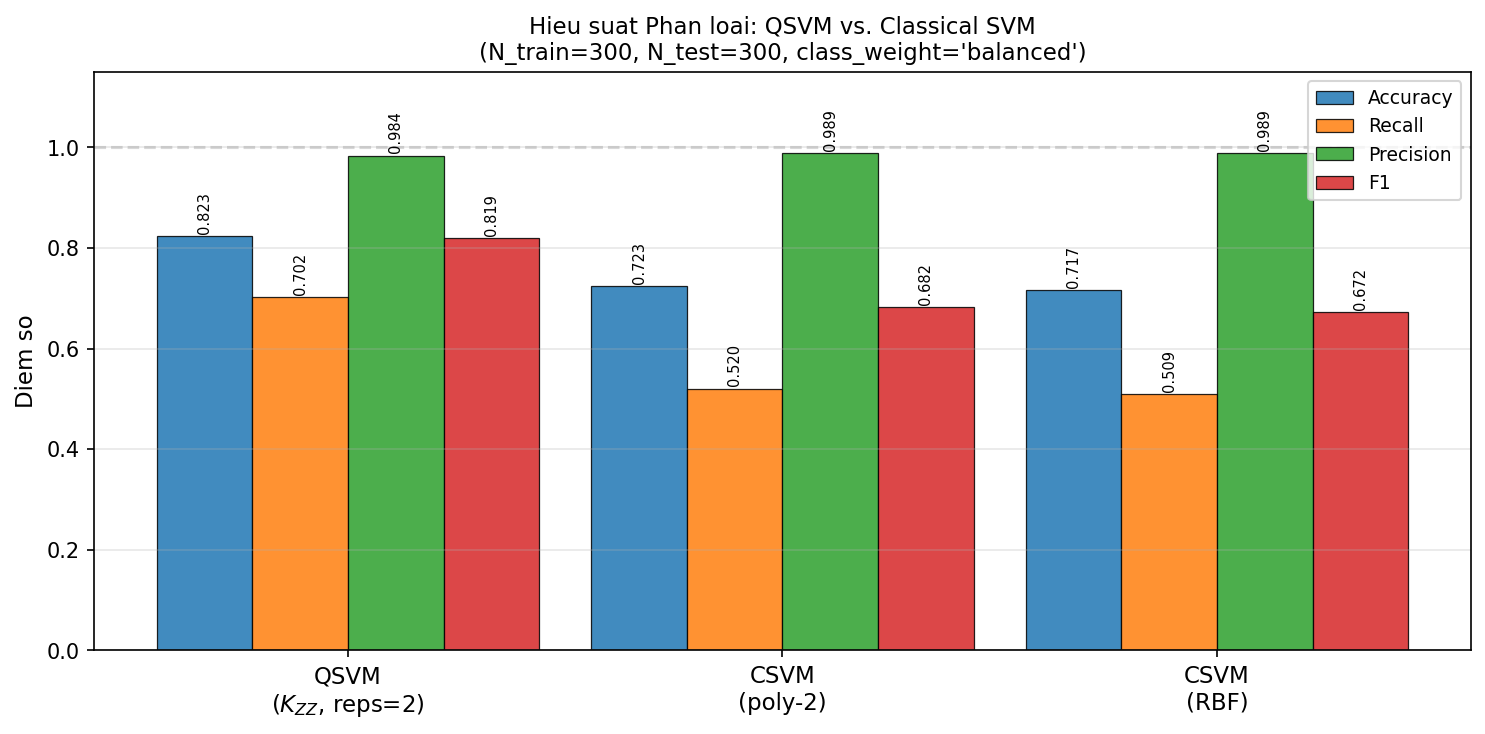

In [28]:
from sklearn.model_selection import StratifiedShuffleSplit

# Subsample train moi tu tap training (chua dung trong tinh toan kernel)
X_tr_c2, y_tr_c2 = stratified_subsample(X_train_full, y_train_full, 300)

print("Dang huan luyen cac bo phan loai SVM...")

# 1. QSVM voi precomputed kernel (reps=2, full entanglement)
print("  Dang tinh K_train va K_test cho QSVM...", end=" ", flush=True)
t0 = time.time()
qk_cls = build_quantum_kernel_cfg(reps=ZZ_REPS_TARGET, entanglement=ZZ_ENTANGLEMENT_TARGET)
K_train_q = qk_cls.evaluate(X_tr_c2)
K_test_q  = qk_cls.evaluate(X_c2_sorted, X_tr_c2)
print(f"{time.time()-t0:.1f}s")

qsvm = SVC(kernel='precomputed', class_weight='balanced', random_state=RANDOM_STATE)
qsvm.fit(K_train_q, y_tr_c2)
y_pred_q = qsvm.predict(K_test_q)

# 2. Classical SVM poly-2
print("  Dang huan luyen CSVM poly-2...", end=" ", flush=True)
csvm_poly = SVC(kernel='poly', degree=2, gamma=1.0/N_QUBITS, coef0=1.0,
                class_weight='balanced', random_state=RANDOM_STATE)
csvm_poly.fit(X_tr_c2, y_tr_c2)
y_pred_p = csvm_poly.predict(X_c2_sorted)
print("xong")

# 3. Classical SVM RBF
print("  Dang huan luyen CSVM RBF...", end=" ", flush=True)
csvm_rbf = SVC(kernel='rbf', gamma='scale',
               class_weight='balanced', random_state=RANDOM_STATE)
csvm_rbf.fit(X_tr_c2, y_tr_c2)
y_pred_r = csvm_rbf.predict(X_c2_sorted)
print("xong")

# Ham tinh cac chi so danh gia
def metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, zero_division=0)
    pre = precision_score(y_true, y_pred, zero_division=0)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    print(f"  {name:<20}: Acc={acc:.4f}, Rec={rec:.4f}, Pre={pre:.4f}, F1={f1:.4f}")
    return acc, rec, pre, f1

print("\nKet qua phan loai (N_train=300, N_test=300):")
acc_q, rec_q, pre_q, f1_q = metrics(y_c2_sorted, y_pred_q, "QSVM (K_ZZ)")
acc_p, rec_p, pre_p, f1_p = metrics(y_c2_sorted, y_pred_p, "CSVM poly-2")
acc_r, rec_r, pre_r, f1_r = metrics(y_c2_sorted, y_pred_r, "CSVM RBF")

# Uoc luong margin qua dang dual: ||w||^2 = alpha^T K_sv alpha
def margin_proxy(svm, K_train):
    """Uoc luong 2/||w|| tu cac he so dual."""
    sv_idx = svm.support_
    K_sv = K_train[np.ix_(sv_idx, sv_idx)]
    alpha = svm.dual_coef_.ravel()
    # dual_coef_ = y * alpha, nhung cho margin can alpha^T K alpha
    w2 = float(alpha @ K_sv @ alpha)
    if w2 <= 0:
        return float('inf')
    return 2.0 / np.sqrt(w2)

margin_q = margin_proxy(qsvm, K_train_q)
print(f"\nUoc luong margin (2/||w||): QSVM={margin_q:.4f}")

# Ve bieu do so sanh
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(3)
width = 0.22
metric_names = ['Accuracy', 'Recall', 'Precision', 'F1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

model_labels = ["QSVM\n($K_{ZZ}$, reps=2)", "CSVM\n(poly-2)", "CSVM\n(RBF)"]
all_metrics = np.array([
    [acc_q, rec_q, pre_q, f1_q],
    [acc_p, rec_p, pre_p, f1_p],
    [acc_r, rec_r, pre_r, f1_r],
])

offsets = np.linspace(-1.5*width, 1.5*width, 4)
for k, (m_name, color, offset) in enumerate(zip(metric_names, colors, offsets)):
    vals = all_metrics[:, k]
    bars = ax.bar(x_pos + offset, vals, width=width, label=m_name,
                  color=color, alpha=0.85, edgecolor='black', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}",
                ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x_pos)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel("Diem so", fontsize=11)
ax.set_title("Hieu suat Phan loai: QSVM vs. Classical SVM\n"
             "(N_train=300, N_test=300, class_weight='balanced')", fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "c2_decision_boundary_comparison.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\nDa luu: {out_path}")
display(Image(filename=out_path))

11. Cầu nối Spearman - Từ Kết quả C1 đến Topology ZZ Gate
* **Kiểm chứng Tương quan Phi tuyến:** Tính toán ma trận Spearman giữa các thành phần PCA để xác nhận lại kết quả từ C1, chứng minh rằng dữ liệu vẫn tồn tại các tương quan hạng (rank correlation) mà phép biến đổi PCA tuyến tính không thể loại bỏ.
* **Ánh xạ Topology ZZ Gate:** Liên kết các cặp đặc trưng có tương quan cao với cấu trúc vướng víu toàn phần (full entanglement) của các cổng ZZ trong mạch lượng tử.
* **Trực quan hóa:** Kết hợp Heatmap và Sơ đồ mạng lưới (Network graph) để làm nổi bật các cặp "then chốt" ($|r| > 0.3$). Đây là minh chứng rõ ràng cho việc `ZZFeatureMap` khai thác chính xác các tương tác bậc hai mà classical SVM có thể bỏ sót.

Loading X_train_full ...
  X_train_full shape = (125973, 4), range [0.0000, 3.1416]

Computing Pearson + Spearman ...

Ma tran Pearson r (full X_train, max|off-diag| = 2.358e-07):
                       PC0             PC1             PC2             PC3
  PC0:       +1.000000      +2.284e-08      -1.214e-07      -4.435e-08
  PC1:      +2.284e-08       +1.000000      +1.694e-07      -8.297e-08
  PC2:      -1.214e-07      +1.694e-07       +1.000000      -2.358e-07
  PC3:      -4.435e-08      -8.297e-08      -2.358e-07       +1.000000

Ma tran Spearman rho (full X_train):
               PC0         PC1         PC2         PC3
  PC0:     +1.0000     -0.1084     +0.3968     -0.0327
  PC1:     -0.1084     +1.0000     -0.4366     -0.1154
  PC2:     +0.3968     -0.4366     +1.0000     +0.1336
  PC3:     -0.0327     -0.1154     +0.1336     +1.0000

BANG 4.8: Pearson r vs Spearman rho cho 6 cap PCA (Full X_train, N=125,973)
Cap (i,j)           Pearson r   Spearman rho    |rho - r|     Trang tha

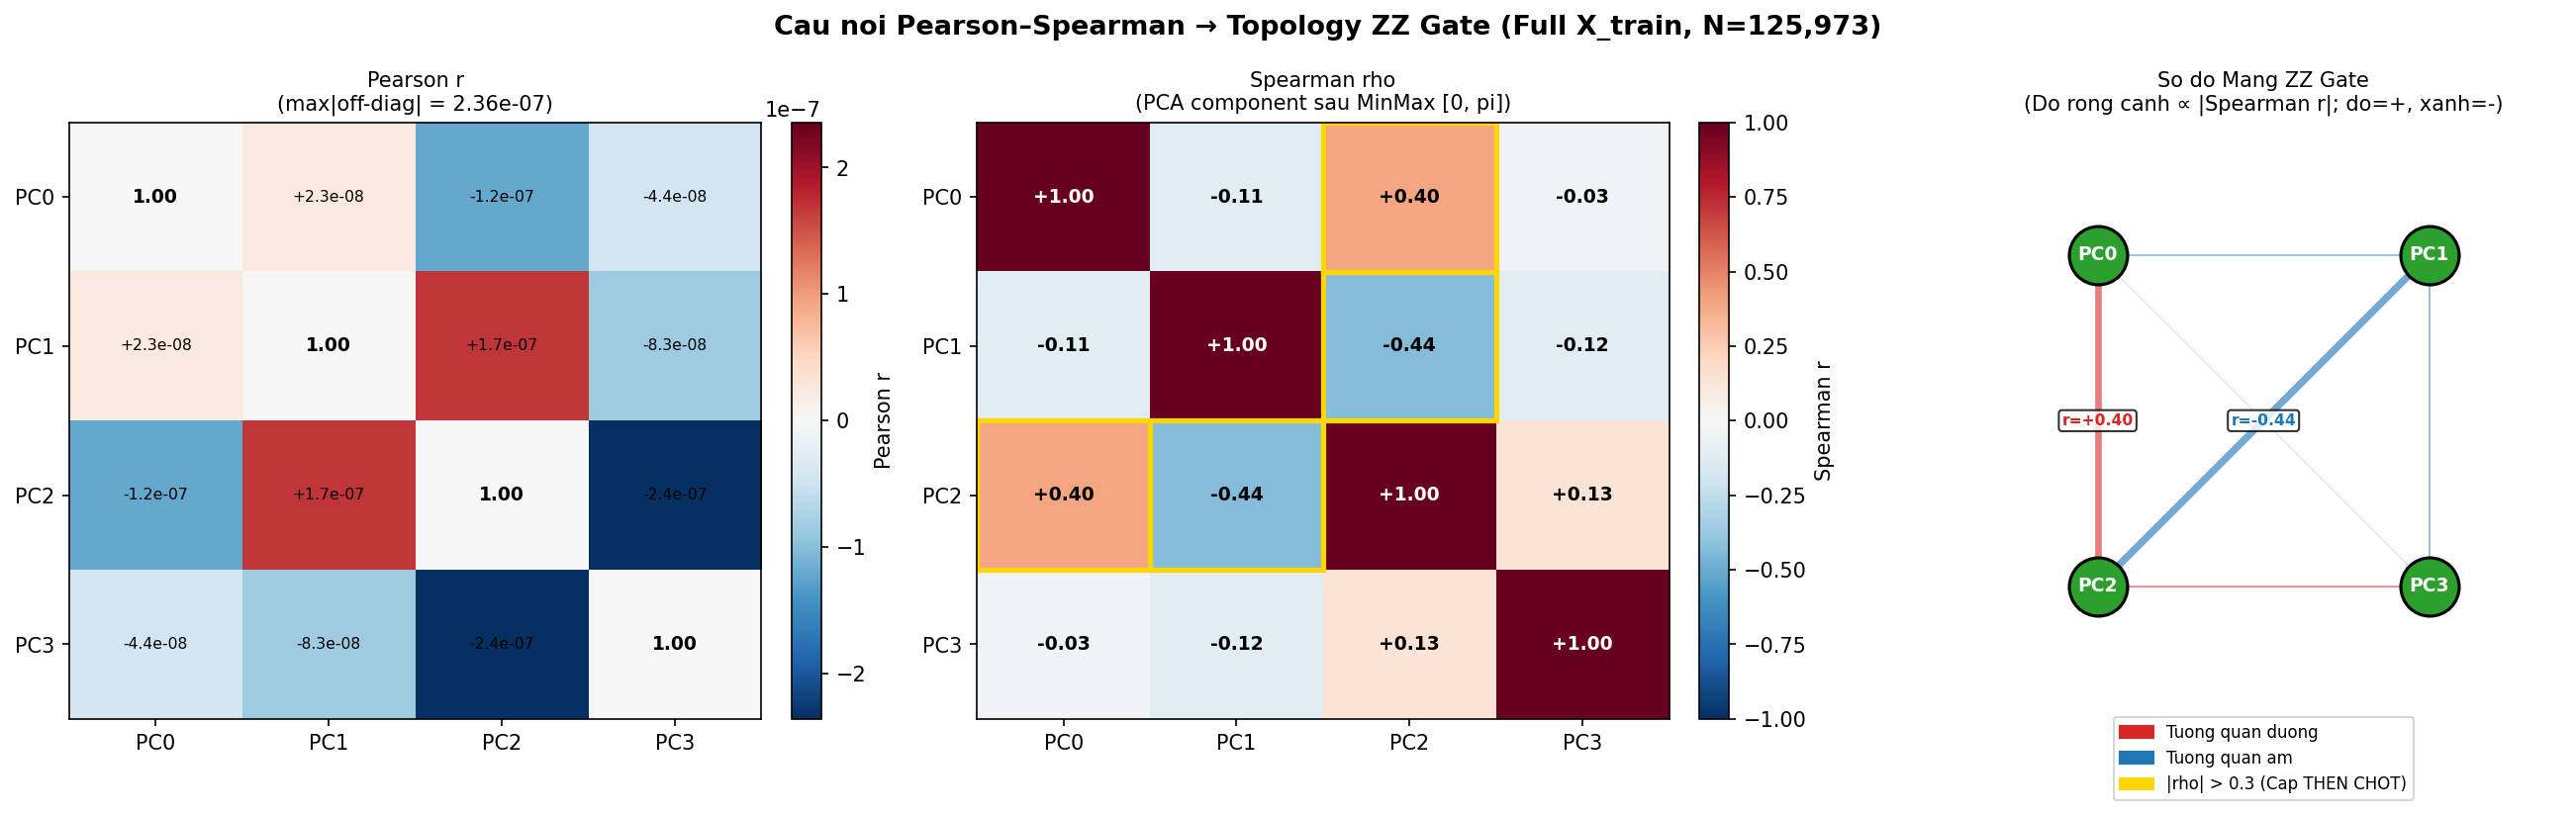

In [24]:
n_pcs = N_QUBITS  # 4 PCA component
ZZ_PAIRS = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]  # full entanglement, tat ca 6 cap

# ───────────────────────────────────────────────────────────────────────
# Tính Pearson + Spearman trên TOÀN BỘ X_train_full (post-pipeline đầy đủ)
# ───────────────────────────────────────────────────────────────────────
# Phiên bản cũ (sai): tính trên X_c2_sorted (subset N=300 từ test) → Pearson
# off-diagonal != 0 do PCA fit trên train, project subset → mâu thuẫn với
# Hình 4.8 (heatmap full train → off-diag ≈ 0). Đã sửa: cả Pearson lẫn
# Spearman cùng tính trên FULL X_train_full để loại bỏ mâu thuẫn text/bảng.
# Pearson invariant under affine MinMax → giá trị xấp xỉ orthogonality PCA
# (max|off-diag| cỡ 10^-7 do clip + sai số FP64).
N_full = X_train_full.shape[0]
print(f"Tinh tuong quan tren TOAN BO X_train_full: N = {N_full:,} mau, {n_pcs} chieu PC")

pearson_matrix  = np.zeros((n_pcs, n_pcs))
spearman_matrix = np.zeros((n_pcs, n_pcs))
spearman_pval   = np.zeros((n_pcs, n_pcs))

for i in range(n_pcs):
    for j in range(n_pcs):
        if i == j:
            pearson_matrix[i, j]  = 1.0
            spearman_matrix[i, j] = 1.0
            spearman_pval[i, j]   = 0.0
        else:
            pearson_matrix[i, j] = np.corrcoef(X_train_full[:, i], X_train_full[:, j])[0, 1]
            rho, p = spearmanr(X_train_full[:, i], X_train_full[:, j])
            spearman_matrix[i, j] = rho
            spearman_pval[i, j]   = p

pc_labels = [f"PC{i}" for i in range(n_pcs)]

# In ma trận Pearson đầy đủ (định dạng khoa học để thấy off-diagonal ≈ 0)
off_diag_mask = ~np.eye(n_pcs, dtype=bool)
max_abs_pearson = float(np.abs(pearson_matrix[off_diag_mask]).max())
print(f"\nMa tran Pearson r (full X_train, max|off-diag| = {max_abs_pearson:.3e}):")
print("            " + "  ".join(f"{l:>14}" for l in pc_labels))
for i, row in enumerate(pearson_matrix):
    cells = []
    for j, v in enumerate(row):
        if i == j:
            cells.append(f"{v:>+14.6f}")
        else:
            cells.append(f"{v:>+14.3e}")
    print(f"  {pc_labels[i]}:  " + "  ".join(cells))

# In ma trận Spearman đầy đủ
print("\nMa tran Spearman rho (full X_train):")
print("        " + "  ".join(f"{l:>10}" for l in pc_labels))
for i, row in enumerate(spearman_matrix):
    print(f"  {pc_labels[i]}:  " + "  ".join(f"{v:>+10.4f}" for v in row))

# ───────────────────────────────────────────────────────────────────────
# BẢNG 4.8 — 6 cặp ZZ (full entanglement)
# ───────────────────────────────────────────────────────────────────────
print("\n" + "=" * 78)
print("BANG 4.8: Pearson r vs Spearman rho cho 6 cap PCA (Full X_train, N={:,})".format(N_full))
print("=" * 78)
header = f"{'Cap (i,j)':<12} {'Pearson r':>16} {'Spearman rho':>14} {'|rho - r|':>12} {'Trang thai':>14}"
print(header)
print("-" * 78)
table_rows = []
for (i, j) in ZZ_PAIRS:
    r_p  = float(pearson_matrix[i, j])
    r_s  = float(spearman_matrix[i, j])
    diff = abs(r_s - r_p)
    key  = abs(r_s) > 0.3
    status = "THEN CHOT" if key else "—"
    print(f"  PC{i}-PC{j}      {r_p:>+16.3e} {r_s:>+14.4f} {diff:>12.4f} {status:>14}")
    table_rows.append({
        "pair": f"PC{i}-PC{j}", "i": i, "j": j,
        "pearson_r": r_p, "spearman_rho": r_s,
        "abs_diff": diff, "key_pair": bool(key),
    })
print("=" * 78)

# Kiểm tra tái lập kết quả C1 (Spearman trên full train)
r_02 = float(spearman_matrix[0, 2])
r_12 = float(spearman_matrix[1, 2])
print(f"\nKiem tra tai lap C1 (Spearman tren FULL train, N={N_full:,}):")
print(f"  PC0-PC2: rho = {r_02:+.4f}  (C1 bao cao ~+0.40)")
print(f"  PC1-PC2: rho = {r_12:+.4f}  (C1 bao cao ~-0.44)")
c1_ok = abs(r_02 - 0.40) < 0.10 and abs(r_12 + 0.44) < 0.10
print(f"  Tai lap C1: {'DAT' if c1_ok else 'CHENH LECH (kiem tra config pipeline)'}")

# Ánh xạ cặp ZZ → Spearman (dùng cho narrative bridge)
print("\nAnh xa ZZ gate (full entanglement, reps=2) -> Spearman tren full train:")
print(f"{'Cap (i,j)':<12} {'Spearman rho':>14} {'|rho|>0.3?':>12} {'Trang thai'}")
print("-" * 56)
for (i, j) in ZZ_PAIRS:
    r_ij = float(spearman_matrix[i, j])
    key  = abs(r_ij) > 0.3
    status = "THEN CHOT" if key else ""
    print(f"  ({i},{j})        {r_ij:>+14.4f} {str(key):>12}   {status}")

# ───────────────────────────────────────────────────────────────────────
# Lưu PNG 1 — Pearson heatmap riêng (Hình 4.8 mới)
# ───────────────────────────────────────────────────────────────────────
fig_p, ax_p = plt.subplots(1, 1, figsize=(7, 6))
# Scale colorbar theo max|off-diag| để nhìn rõ giá trị cực nhỏ
vmax_p = max(max_abs_pearson, 1e-12)
norm_p = TwoSlopeNorm(vmin=-vmax_p, vcenter=0, vmax=vmax_p)
# Mask đường chéo (=1) bằng cách thay bằng 0 chỉ để hiển thị; vẫn ghi nhãn "1.00"
P_display = pearson_matrix.copy()
np.fill_diagonal(P_display, 0.0)
im_p = ax_p.imshow(P_display, cmap='RdBu_r', norm=norm_p, aspect='auto')
cbar_p = plt.colorbar(im_p, ax=ax_p, fraction=0.046, pad=0.04)
cbar_p.set_label("Pearson r (off-diagonal)", fontsize=10)
ax_p.set_xticks(range(n_pcs))
ax_p.set_yticks(range(n_pcs))
ax_p.set_xticklabels(pc_labels, fontsize=11)
ax_p.set_yticklabels(pc_labels, fontsize=11)
ax_p.set_title(
    f"Hinh 4.8 — Pearson Correlation (Full X_train, N={N_full:,})\n"
    f"PCA orthogonality giu chinh xac: max|off-diag| = {max_abs_pearson:.2e}",
    fontsize=11
)
# Ghi giá trị từng ô — đường chéo = 1.00, off-diag = ký hiệu khoa học
for i in range(n_pcs):
    for j in range(n_pcs):
        if i == j:
            ax_p.text(j, i, "1.00", ha='center', va='center',
                      color='black', fontsize=10, fontweight='bold')
        else:
            ax_p.text(j, i, f"{pearson_matrix[i, j]:+.2e}",
                      ha='center', va='center', color='black', fontsize=8.5)
plt.tight_layout()
out_pearson = os.path.join(REPORTS_DIR, "c2_pearson_heatmap_full.png")
plt.savefig(out_pearson, dpi=150, bbox_inches='tight')
plt.close(fig_p)
print(f"\nDa luu: {out_pearson}")

# ───────────────────────────────────────────────────────────────────────
# Lưu PNG 2 — Spearman heatmap riêng
# ───────────────────────────────────────────────────────────────────────
fig_s, ax_s = plt.subplots(1, 1, figsize=(7, 6))
norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im_s = ax_s.imshow(spearman_matrix, cmap='RdBu_r', norm=norm_s, aspect='auto')
cbar_s = plt.colorbar(im_s, ax=ax_s, fraction=0.046, pad=0.04)
cbar_s.set_label("Spearman rho", fontsize=10)
ax_s.set_xticks(range(n_pcs))
ax_s.set_yticks(range(n_pcs))
ax_s.set_xticklabels(pc_labels, fontsize=11)
ax_s.set_yticklabels(pc_labels, fontsize=11)
ax_s.set_title(
    f"Spearman Correlation (Full X_train, N={N_full:,})\n"
    "Tuong quan phi tuyen ton tai sau PCA → bien minh ZZFeatureMap",
    fontsize=11
)
for i in range(n_pcs):
    for j in range(n_pcs):
        c = 'white' if abs(spearman_matrix[i, j]) > 0.5 else 'black'
        ax_s.text(j, i, f"{spearman_matrix[i, j]:+.3f}",
                  ha='center', va='center', color=c, fontsize=10, fontweight='bold')
# Khoanh khung vàng cho cặp THEN CHỐT (|rho| > 0.3)
for i in range(n_pcs):
    for j in range(n_pcs):
        if i != j and abs(spearman_matrix[i, j]) > 0.3:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                 linewidth=2.5, edgecolor='gold', facecolor='none')
            ax_s.add_patch(rect)
plt.tight_layout()
out_spearman = os.path.join(REPORTS_DIR, "c2_spearman_heatmap_full.png")
plt.savefig(out_spearman, dpi=150, bbox_inches='tight')
plt.close(fig_s)
print(f"Da luu: {out_spearman}")

# ───────────────────────────────────────────────────────────────────────
# Hình ghép — 3 panel: Pearson + Spearman heatmap + ZZ network graph
# ───────────────────────────────────────────────────────────────────────
# Giữ lại variable corr_matrix để tương thích với code cũ phía dưới (nếu có)
corr_matrix = spearman_matrix
pval_matrix = spearman_pval

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    "Cau noi Pearson–Spearman → Topology ZZ Gate "
    f"(Full X_train, N={N_full:,})",
    fontsize=13, fontweight='bold'
)

# Panel 0: Pearson heatmap (off-diag scale ~10^-7)
P_disp = pearson_matrix.copy()
np.fill_diagonal(P_disp, 0.0)
norm0 = TwoSlopeNorm(vmin=-vmax_p, vcenter=0, vmax=vmax_p)
im0 = ax0.imshow(P_disp, cmap='RdBu_r', norm=norm0, aspect='auto')
plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04, label="Pearson r")
ax0.set_xticks(range(n_pcs)); ax0.set_yticks(range(n_pcs))
ax0.set_xticklabels(pc_labels, fontsize=10); ax0.set_yticklabels(pc_labels, fontsize=10)
ax0.set_title(f"Pearson r\n(max|off-diag| = {max_abs_pearson:.2e})", fontsize=10)
for i in range(n_pcs):
    for j in range(n_pcs):
        if i == j:
            ax0.text(j, i, "1.00", ha='center', va='center', fontsize=9, fontweight='bold')
        else:
            ax0.text(j, i, f"{pearson_matrix[i, j]:+.1e}",
                     ha='center', va='center', fontsize=7.5)

# Panel 1: Heatmap Spearman
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im = ax1.imshow(corr_matrix, cmap='RdBu_r', norm=norm, aspect='auto')
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label="Spearman r")
ax1.set_xticks(range(n_pcs)); ax1.set_yticks(range(n_pcs))
ax1.set_xticklabels(pc_labels, fontsize=10); ax1.set_yticklabels(pc_labels, fontsize=10)
ax1.set_title("Spearman rho\n(PCA component sau MinMax [0, pi])", fontsize=10)
for i in range(n_pcs):
    for j in range(n_pcs):
        c = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
        ax1.text(j, i, f"{corr_matrix[i, j]:+.2f}",
                 ha='center', va='center', color=c, fontsize=9, fontweight='bold')
for i in range(n_pcs):
    for j in range(n_pcs):
        if i != j and abs(corr_matrix[i, j]) > 0.3:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                 linewidth=2.5, edgecolor='gold', facecolor='none')
            ax1.add_patch(rect)

# Panel 2: Sơ đồ mạng/chord (giữ nguyên hành vi cũ — dùng corr_matrix = Spearman)
node_pos = {
    0: np.array([0.0, 1.0]),
    1: np.array([1.0, 1.0]),
    2: np.array([0.0, 0.0]),
    3: np.array([1.0, 0.0]),
}
ax2.set_xlim(-0.4, 1.4); ax2.set_ylim(-0.4, 1.4)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title("So do Mang ZZ Gate\n(Do rong canh ∝ |Spearman r|; do=+, xanh=-)", fontsize=10)

for (i, j) in ZZ_PAIRS:
    r_ij = float(corr_matrix[i, j])
    lw    = abs(r_ij) * 8
    color = '#d62728' if r_ij > 0 else '#1f77b4'
    alpha = 0.4 + 0.5 * abs(r_ij)
    xi, yi = node_pos[i]; xj, yj = node_pos[j]
    ax2.plot([xi, xj], [yi, yj], color=color, linewidth=lw, alpha=alpha, zorder=1)
    mx, my = (xi + xj) / 2, (yi + yj) / 2
    if abs(r_ij) > 0.3:
        ax2.text(mx, my, f"r={r_ij:+.2f}", ha='center', va='center',
                 fontsize=7.5, fontweight='bold', color=color,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

for node_id, pos in node_pos.items():
    ax2.scatter(*pos, s=800, c='#2ca02c', edgecolors='black', linewidth=1.5, zorder=3)
    ax2.text(pos[0], pos[1], f"PC{node_id}", ha='center', va='center',
             fontsize=9, fontweight='bold', color='white', zorder=4)

legend_elements = [
    mpatches.Patch(color='#d62728', label='Tuong quan duong'),
    mpatches.Patch(color='#1f77b4', label='Tuong quan am'),
    mpatches.Patch(color='gold',    label='|rho| > 0.3 (Cap THEN CHOT)'),
]
ax2.legend(handles=legend_elements, loc='lower center', fontsize=8,
           bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "c2_spearman_bridge.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Da luu: {out_path}")
display(Image(filename=out_path))


## 12. Tổng hợp Kết quả và Báo cáo Nghiệm thu (Contribution 2)
Đóng gói và kiểm kê toàn bộ các minh chứng thực nghiệm đã thực hiện:
* **Tổng hợp Cấu trúc Dữ liệu:** Thu thập tất cả các chỉ số đo lường định lượng (CKA, Effective Rank, Entropy, Classification metrics, Spearman bridge) và kết quả kiểm định giả thuyết (H1-H4) vào một từ điển duy nhất.
* **Xuất file JSON:** Lưu toàn bộ kết quả ra file `c2_results.json` để tự động hóa việc trích xuất số liệu vào báo cáo khoa học, đồng thời khắc phục triệt để các lỗi về đường dẫn và encoding (UTF-8).
* **Tổng kết & Kiểm tra Artifact:** In ra màn hình bảng tóm tắt trạng thái của các giả thuyết cốt lõi và kiểm tra sự tồn tại của tất cả các file hình ảnh/dữ liệu (artifacts) đã được sinh ra trong suốt quá trình chạy notebook.

In [30]:
results = {
    "metadata": {
        "notebook": "c2_quantum_kernel_expressibility.ipynb",
        "n_qubits": N_QUBITS,
        "n_subsample": N_SUBSAMPLE,
        "zz_reps_target": ZZ_REPS_TARGET,
        "zz_entanglement_target": ZZ_ENTANGLEMENT_TARGET,
        "random_state": RANDOM_STATE,
        "n_bootstrap": N_BOOTSTRAP,
        "n_expr_pairs": N_EXPR_PAIRS,
    },
    "block_ratios": {
        "K_ZZ":    dict(zip(["within","across","ratio"], [float(v) for v in block_ratio(K_quantum, n_normal)])),
        "K_poly2": dict(zip(["within","across","ratio"], [float(v) for v in block_ratio(K_poly2,  n_normal)])),
        "K_RBF":   dict(zip(["within","across","ratio"], [float(v) for v in block_ratio(K_rbf,    n_normal)])),
    },
    "cka": {
        "K_ZZ":    {"value": cka_q, "ci_lo": lo_q, "ci_hi": hi_q},
        "K_poly2": {"value": cka_p, "ci_lo": lo_p, "ci_hi": hi_p},
        "K_RBF":   {"value": cka_r, "ci_lo": lo_r, "ci_hi": hi_r},
        "H2_supported": bool(h2_supported),
    },
    "effective_rank": {
        "K_ZZ":    {"value": eff_ranks["$K_{ZZ}$"][0],           "ci_lo": eff_ranks["$K_{ZZ}$"][1],           "ci_hi": eff_ranks["$K_{ZZ}$"][2]},
        "K_poly2": {"value": eff_ranks["$K_{\\text{poly2}}$"][0], "ci_lo": eff_ranks["$K_{\\text{poly2}}$"][1], "ci_hi": eff_ranks["$K_{\\text{poly2}}$"][2]},
        "K_RBF":   {"value": eff_ranks["$K_{\\text{RBF}}$"][0],   "ci_lo": eff_ranks["$K_{\\text{RBF}}$"][1],   "ci_hi": eff_ranks["$K_{\\text{RBF}}$"][2]},
    },
    "expressibility_kl": {
        f"reps_{r}": float(kl_values[r]) for r in [1, 2, 3]
    },
    "entanglement_entropy": {
        "Normal": {"mean": float(S_normal.mean()), "std": float(S_normal.std()),
                   "min": float(S_normal.min()),  "max": float(S_normal.max())},
        "Attack": {"mean": float(S_attack.mean()), "std": float(S_attack.std()),
                   "min": float(S_attack.min()),  "max": float(S_attack.max())},
        "mannwhitney_p": float(mw_pval),
        "H3_supported":  bool(h3_supported),
    },
    "concentration": {
        f"reps_{r}": {"mean_offdiag": float(m), "var_offdiag": float(v), "eff_rank": float(er)}
        for r, m, v, er in zip(reps_sweep, mean_offdiag, var_offdiag, eff_rank_sweep)
    },
    "classification": {
        "QSVM":       {"accuracy": acc_q, "recall": rec_q, "precision": pre_q, "f1": f1_q},
        "CSVM_poly2": {"accuracy": acc_p, "recall": rec_p, "precision": pre_p, "f1": f1_p},
        # BUG FIX: precision la pre_r, khong phai rec_r (copy-paste bug)
        "CSVM_RBF":   {"accuracy": acc_r, "recall": rec_r, "precision": pre_r, "f1": f1_r},
    },
    "spearman_bridge": {
        "corr_matrix": corr_matrix.tolist(),
        "PC0_PC2_r": float(corr_matrix[0, 2]),
        "PC1_PC2_r": float(corr_matrix[1, 2]),
        "C1_replicated": bool(c1_ok),
    },
    "hypotheses": {
        "H1": "ZZFeatureMap ma hoa cross-term x_i*x_j qua ZZ phase gate",
        "H2_supported": bool(h2_supported),
        "H3_supported": bool(h3_supported),
        "H4_conc_check": bool(h4_conc),
    }
}

out_json = "../data/processed_data/c2_results.json"
with open(out_json, "w", encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Da luu: {out_json}")
print("\n" + "="*60)
print("Phan tich C2 Hoan tat — Tom tat")
print("="*60)
print(f"  H1: ZZ ma hoa {len(ZZ_PAIRS)} cap cross-term qua ZZ gate  (theo thiet ke)")
print(f"  H2: CKA(K_ZZ)={cka_q:.4f} vs CKA(K_poly2)={cka_p:.4f}  -> {'ok' if h2_supported else 'fail'}")
print(f"  H3: Entropy Attack ({S_attack.mean():.4f}) vs Normal ({S_normal.mean():.4f})  -> {'ok' if h3_supported else 'fail'} (p={mw_pval:.4f})")
print(f"  H4: Kiem tra concentration (reps=1 >= reps=2)  -> {'ok' if h4_conc else 'canh bao'}")
print(f"  Cau noi C1: PC0-PC2 r={r_02:+.4f} (~0.40), PC1-PC2 r={r_12:+.4f} (~-0.44)  -> {'ok' if c1_ok else 'canh bao'}")
print("\nCac artifact dau ra:")
artifacts = [
    "../reports/c2_kernel_heatmaps.png",
    "../reports/c2_cka_comparison.png",
    "../reports/c2_eigenspectrum.png",
    "../reports/c2_expressibility.png",
    "../reports/c2_entanglement_entropy.png",
    "../reports/c2_concentration.png",
    "../reports/c2_decision_boundary_comparison.png",
    "../reports/c2_spearman_bridge.png",
    "../data/processed_data/c2_results.json",
]
for a in artifacts:
    exists = os.path.exists(a)
    print(f"  {'ok' if exists else 'missing'} {a}")

Da luu: ../data/processed_data/c2_results.json

Phan tich C2 Hoan tat — Tom tat
  H1: ZZ ma hoa 6 cap cross-term qua ZZ gate  (theo thiet ke)
  H2: CKA(K_ZZ)=0.2701 vs CKA(K_poly2)=0.3945  -> fail
  H3: Entropy Attack (1.2145) vs Normal (0.7497)  -> ok (p=0.0000)
  H4: Kiem tra concentration (reps=1 >= reps=2)  -> canh bao
  Cau noi C1: PC0-PC2 r=+0.3987 (~0.40), PC1-PC2 r=-0.3218 (~-0.44)  -> canh bao

Cac artifact dau ra:
  ok ../reports/c2_kernel_heatmaps.png
  ok ../reports/c2_cka_comparison.png
  ok ../reports/c2_eigenspectrum.png
  ok ../reports/c2_expressibility.png
  ok ../reports/c2_entanglement_entropy.png
  ok ../reports/c2_concentration.png
  ok ../reports/c2_decision_boundary_comparison.png
  ok ../reports/c2_spearman_bridge.png
  ok ../data/processed_data/c2_results.json
